In [1]:
#Colab 환경 확인. LMS 처럼 굳이 다운그레이드 하지 않더라도 가능하도록 세팅하고 싶음.
import sys
import os
import platform
import importlib.util

print("Python :", sys.version.split()[0])
print("Platform:", platform.platform())
print("CPU     :", os.cpu_count())

packages = [
    "gdown",
    "konlpy",
    "gensim",
    "sklearn",
    "numpy",
    "scipy",
    "seaborn",
    "matplotlib",
]

print("\n[Package availability]")
for pkg in packages:
    print(f"{pkg:12s}:", "OK" if importlib.util.find_spec(pkg) else "MISSING")

Python : 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
CPU     : 2

[Package availability]
gdown       : OK
konlpy      : MISSING
gensim      : MISSING
sklearn     : OK
numpy       : OK
scipy       : OK
seaborn     : OK
matplotlib  : OK


In [2]:
!pip install -q konlpy gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 29.1 MB/s eta 0:00:00


In [3]:
import gdown
import konlpy
import gensim
import sklearn
import numpy as np
import scipy
import seaborn as sns
import matplotlib
import sys

print("Python       :", sys.version.split()[0])
print("gdown        :", gdown.__version__)
print("KoNLPy       :", konlpy.__version__)
print("Gensim       :", gensim.__version__)
print("scikit-learn :", sklearn.__version__)
print("NumPy        :", np.__version__)
print("SciPy        :", scipy.__version__)
print("Seaborn      :", sns.__version__)
print("Matplotlib   :", matplotlib.__version__)

Python       : 3.12.13
gdown        : 5.2.2
KoNLPy       : 0.6.0
Gensim       : 4.4.0
scikit-learn : 1.6.1
NumPy        : 2.0.2
SciPy        : 1.16.3
Seaborn      : 0.13.2
Matplotlib   : 3.10.0


In [4]:
#KoNLPy 스모크테스트 해보기.
from konlpy.tag import Okt

okt = Okt()

test_text = "오늘은 ~ 예술영화와 일반영화의 시놉시스를 분석하여 영화 장르의 편향성을 알아봅니다."

print("명사 추출:", okt.nouns(test_text))

명사 추출: ['오늘', '예술', '영화', '영화', '시놉시스', '분석', '영화', '장르', '편향']


In [5]:
#드라이브 경로 세팅하기
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from pathlib import Path

ROOT_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher"
)

DATA_DIR = ROOT_DIR / "data" / "EX05_word2vec_weat"
MODEL_DIR = ROOT_DIR / "models" / "EX05_word2vec_weat"
OUTPUT_DIR = ROOT_DIR / "outputs" / "EX05_word2vec_weat"

TOKEN_DIR = OUTPUT_DIR / "tokenized"
WORDSET_DIR = OUTPUT_DIR / "wordsets"
FIGURE_DIR = OUTPUT_DIR / "figures"
RESULT_DIR = OUTPUT_DIR / "results"

for path in [
    DATA_DIR,
    MODEL_DIR,
    TOKEN_DIR,
    WORDSET_DIR,
    FIGURE_DIR,
    RESULT_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("ROOT   :", ROOT_DIR)
print("DATA   :", DATA_DIR)
print("MODEL  :", MODEL_DIR)
print("OUTPUT :", OUTPUT_DIR)

ROOT   : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher
DATA   : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/EX05_word2vec_weat
MODEL  : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/EX05_word2vec_weat
OUTPUT : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX05_word2vec_weat


In [7]:
import gdown

zip_path = DATA_DIR / "synopsis.zip"

gdown.download(
    id="19NmxfaX7tJn6dAGvq-EM1wfw63momOq0",
    output=str(zip_path),
    quiet=False
)

print("\n[다운로드 확인]")
print("파일 경로 :", zip_path)
print("존재 여부 :", zip_path.exists())

if zip_path.exists():
    print("파일 크기 :", round(zip_path.stat().st_size / (1024**2), 2), "MB")

Downloading...
From: https://drive.google.com/uc?id=19NmxfaX7tJn6dAGvq-EM1wfw63momOq0
To: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/EX05_word2vec_weat/synopsis.zip
100%|██████████| 18.4M/18.4M [00:00<00:00, 52.3MB/s]


[다운로드 확인]
파일 경로 : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/EX05_word2vec_weat/synopsis.zip
존재 여부 : True
파일 크기 : 17.55 MB


In [8]:
import zipfile

with zipfile.ZipFile(zip_path, "r") as zf:
    zip_files = zf.namelist()

print("압축 내부 파일 수:", len(zip_files))
print("\n[압축 내부 파일 목록]")

for name in zip_files:
    print("-", name)

압축 내부 파일 수: 24

[압축 내부 파일 목록]
- synopsis.txt
- synopsis_SF.txt
- synopsis_action.txt
- synopsis_adult.txt
- synopsis_adventure.txt
- synopsis_animation.txt
- synopsis_art.txt
- synopsis_comedy.txt
- synopsis_crime.txt
- synopsis_documentary.txt
- synopsis_drama.txt
- synopsis_etc.txt
- synopsis_family.txt
- synopsis_fantasy.txt
- synopsis_gen.txt
- synopsis_historical.txt
- synopsis_horror.txt
- synopsis_musical.txt
- synopsis_mystery.txt
- synopsis_romance.txt
- synopsis_show.txt
- synopsis_thriller.txt
- synopsis_war.txt
- synopsis_western.txt


In [9]:
#내 드라이브 경로에 맞게 압축 해제
EXTRACT_DIR = DATA_DIR / "synopsis"

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(EXTRACT_DIR)

print("압축 해제 완료")
print("압축 해제 경로:", EXTRACT_DIR)

압축 해제 완료
압축 해제 경로: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/EX05_word2vec_weat/synopsis


In [10]:
txt_files = sorted(EXTRACT_DIR.rglob("*.txt"))

print("TXT 파일 수:", len(txt_files))
print()

for path in txt_files:
    size_mb = path.stat().st_size / (1024**2)

    print(
        f"{path.relative_to(EXTRACT_DIR)}"
        f" | {size_mb:.2f} MB"
    )

TXT 파일 수: 24

synopsis.txt | 16.93 MB
synopsis_SF.txt | 0.26 MB
synopsis_action.txt | 1.39 MB
synopsis_adult.txt | 0.58 MB
synopsis_adventure.txt | 0.12 MB
synopsis_animation.txt | 1.56 MB
synopsis_art.txt | 2.61 MB
synopsis_comedy.txt | 1.33 MB
synopsis_crime.txt | 0.35 MB
synopsis_documentary.txt | 1.92 MB
synopsis_drama.txt | 4.91 MB
synopsis_etc.txt | 0.61 MB
synopsis_family.txt | 0.10 MB
synopsis_fantasy.txt | 0.15 MB
synopsis_gen.txt | 12.78 MB
synopsis_historical.txt | 0.04 MB
synopsis_horror.txt | 0.73 MB
synopsis_musical.txt | 0.04 MB
synopsis_mystery.txt | 0.19 MB
synopsis_romance.txt | 1.29 MB
synopsis_show.txt | 0.10 MB
synopsis_thriller.txt | 0.53 MB
synopsis_war.txt | 0.10 MB
synopsis_western.txt | 0.01 MB


In [11]:
#프로젝트 데이터 검증
required_files = [
    "synopsis.txt",
    "synopsis_art.txt",
    "synopsis_gen.txt",
]

file_by_name = {
    path.name: path
    for path in txt_files
}

print("[필수 파일 검사]")

for filename in required_files:
    if filename in file_by_name:
        print(f"✅ {filename}")
        print("   ", file_by_name[filename])
    else:
        print(f"❌ {filename} : 찾지 못함")

[필수 파일 검사]
✅ synopsis.txt
    /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/EX05_word2vec_weat/synopsis/synopsis.txt
✅ synopsis_art.txt
    /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/EX05_word2vec_weat/synopsis/synopsis_art.txt
✅ synopsis_gen.txt
    /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/EX05_word2vec_weat/synopsis/synopsis_gen.txt


In [12]:
# 변수로 세팅하기
SYNOPSIS_PATH = file_by_name["synopsis.txt"]
ART_PATH = file_by_name["synopsis_art.txt"]
GEN_PATH = file_by_name["synopsis_gen.txt"]

print("전체 시놉시스 :", SYNOPSIS_PATH)
print("예술영화      :", ART_PATH)
print("일반영화      :", GEN_PATH)

전체 시놉시스 : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/EX05_word2vec_weat/synopsis/synopsis.txt
예술영화      : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/EX05_word2vec_weat/synopsis/synopsis_art.txt
일반영화      : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/EX05_word2vec_weat/synopsis/synopsis_gen.txt


In [13]:
# 장르 파일 검증 - 이름 잘 맞춰졌는지 체크
genre_txt = [
    'synopsis_SF.txt',
    'synopsis_family.txt',
    'synopsis_show.txt',
    'synopsis_horror.txt',
    'synopsis_etc.txt',
    'synopsis_documentary.txt',
    'synopsis_drama.txt',
    'synopsis_romance.txt',
    'synopsis_musical.txt',
    'synopsis_mystery.txt',
    'synopsis_crime.txt',
    'synopsis_historical.txt',
    'synopsis_western.txt',
    'synopsis_adult.txt',
    'synopsis_thriller.txt',
    'synopsis_animation.txt',
    'synopsis_action.txt',
    'synopsis_adventure.txt',
    'synopsis_war.txt',
    'synopsis_comedy.txt',
    'synopsis_fantasy.txt'
]

genre_name = [
    'SF',
    '가족',
    '공연',
    '공포(호러)',
    '기타',
    '다큐멘터리',
    '드라마',
    '멜로로맨스',
    '뮤지컬',
    '미스터리',
    '범죄',
    '사극',
    '서부극(웨스턴)',
    '성인물(에로)',
    '스릴러',
    '애니메이션',
    '액션',
    '어드벤처',
    '전쟁',
    '코미디',
    '판타지'
]

print("[장르 파일 검사]")

missing_genres = []

for filename, genre in zip(genre_txt, genre_name):
    if filename in file_by_name:
        print(f"✅ {genre:10s} | {filename}")
    else:
        print(f"❌ {genre:10s} | {filename}")
        missing_genres.append(filename)

print()
print("정상:", len(genre_txt) - len(missing_genres))
print("누락:", len(missing_genres))

[장르 파일 검사]
✅ SF         | synopsis_SF.txt
✅ 가족         | synopsis_family.txt
✅ 공연         | synopsis_show.txt
✅ 공포(호러)     | synopsis_horror.txt
✅ 기타         | synopsis_etc.txt
✅ 다큐멘터리      | synopsis_documentary.txt
✅ 드라마        | synopsis_drama.txt
✅ 멜로로맨스      | synopsis_romance.txt
✅ 뮤지컬        | synopsis_musical.txt
✅ 미스터리       | synopsis_mystery.txt
✅ 범죄         | synopsis_crime.txt
✅ 사극         | synopsis_historical.txt
✅ 서부극(웨스턴)   | synopsis_western.txt
✅ 성인물(에로)    | synopsis_adult.txt
✅ 스릴러        | synopsis_thriller.txt
✅ 애니메이션      | synopsis_animation.txt
✅ 액션         | synopsis_action.txt
✅ 어드벤처       | synopsis_adventure.txt
✅ 전쟁         | synopsis_war.txt
✅ 코미디        | synopsis_comedy.txt
✅ 판타지        | synopsis_fantasy.txt

정상: 21
누락: 0


In [14]:
#  장르명과 실제 파일 경로를 매핑함. 이후에 딕셔너리 재활용을 위함
GENRE_PATHS = {
    genre: file_by_name[filename]
    for genre, filename in zip(genre_name, genre_txt)
    if filename in file_by_name
}

for genre, path in GENRE_PATHS.items():
    print(f"{genre:12s} -> {path.name}")

SF           -> synopsis_SF.txt
가족           -> synopsis_family.txt
공연           -> synopsis_show.txt
공포(호러)       -> synopsis_horror.txt
기타           -> synopsis_etc.txt
다큐멘터리        -> synopsis_documentary.txt
드라마          -> synopsis_drama.txt
멜로로맨스        -> synopsis_romance.txt
뮤지컬          -> synopsis_musical.txt
미스터리         -> synopsis_mystery.txt
범죄           -> synopsis_crime.txt
사극           -> synopsis_historical.txt
서부극(웨스턴)     -> synopsis_western.txt
성인물(에로)      -> synopsis_adult.txt
스릴러          -> synopsis_thriller.txt
애니메이션        -> synopsis_animation.txt
액션           -> synopsis_action.txt
어드벤처         -> synopsis_adventure.txt
전쟁           -> synopsis_war.txt
코미디          -> synopsis_comedy.txt
판타지          -> synopsis_fantasy.txt


### 현재까지 세팅된 구조


```
MyDrive/
└── Colab Notebooks/
    └── 2026.789_AI researcher/
        │
        ├── EX05_Word2Vec_WEAT.ipynb
        │
        ├── data/
        │   └── EX05_word2vec_weat/
        │       ├── synopsis.zip
        │       └── synopsis/
        │           ├── synopsis.txt
        │           ├── synopsis_art.txt
        │           ├── synopsis_gen.txt
        │           └── 장르별 txt 21개
        │
        ├── models/
        │   └── EX05_word2vec_weat/
        │
        └── outputs/
            └── EX05_word2vec_weat/
                ├── tokenized/
                ├── wordsets/
                ├── figures/
                └── results/
```



# Step 1 형태소 분석하기!

In [15]:
# synopsis.txt의 실제 구조 확인하기
# STEP 1-1. synopsis.txt 구조 확인

sample_lines = []
total_lines = 0
empty_lines = 0

with open(SYNOPSIS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        total_lines += 1
        text = line.strip()

        if not text:
            empty_lines += 1
            continue

        if len(sample_lines) < 5:
            sample_lines.append(text)

print("[synopsis.txt 구조]")
print("전체 줄 수 :", total_lines)
print("빈 줄 수   :", empty_lines)
print("유효 줄 수 :", total_lines - empty_lines)

print("\n[앞의 5개 샘플]")
for i, text in enumerate(sample_lines, 1):
    print(f"\n--- SAMPLE {i} ---")
    print(text[:500])

[synopsis.txt 구조]
전체 줄 수 : 71156
빈 줄 수   : 0
유효 줄 수 : 71156

[앞의 5개 샘플]

--- SAMPLE 1 ---
사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와

--- SAMPLE 2 ---
젊은 시절 상처한 한 아버지(박인환 분), 고모(신신애 분)와 함께 살고 있다.

--- SAMPLE 3 ---
어느 겨울 그는 지방 방송국 라디오 PD 은수(이영애 분)를 만난다.

--- SAMPLE 4 ---
자연의 소리를 채집해 틀어주는 라디오 프로그램을 준비하는 은수는 상우와 녹음 여행을 떠난다.

--- SAMPLE 5 ---
자연스레 가까워지는 두 사람은 어느 날, 은수의 아파트에서 밤을 보낸다.


In [16]:
# 명사 추출 테스트
# STEP 1-2. Okt 명사 추출 smoke test

from konlpy.tag import Okt

okt = Okt()

for i, text in enumerate(sample_lines[:3], 1):
    nouns = okt.nouns(text)

    print(f"\n--- SAMPLE {i} ---")
    print("[원문]")
    print(text[:300])

    print("\n[명사]")
    print(nouns[:50])


--- SAMPLE 1 ---
[원문]
사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와

[명사]
['사운드', '엔지니어', '상우', '유지태', '분', '치매', '할머니', '백성희', '분']

--- SAMPLE 2 ---
[원문]
젊은 시절 상처한 한 아버지(박인환 분), 고모(신신애 분)와 함께 살고 있다.

[명사]
['시절', '상처', '아버지', '박인환', '분', '고모', '신신애', '분', '살']

--- SAMPLE 3 ---
[원문]
어느 겨울 그는 지방 방송국 라디오 PD 은수(이영애 분)를 만난다.

[명사]
['겨울', '그', '지방', '방송국', '라디오', '은수', '이영애', '분', '를']


In [17]:
# 처리 속도 가늠해보기
# STEP 1-3. Okt 처리 속도 사전 측정

from itertools import islice
from time import perf_counter

preview_texts = []

with open(SYNOPSIS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        text = line.strip()

        if text:
            preview_texts.append(text)

        if len(preview_texts) >= 100:
            break

start = perf_counter()

preview_tokenized = [
    okt.nouns(text)
    for text in preview_texts
]

elapsed = perf_counter() - start

print("[100개 시놉시스 테스트]")
print("처리 문서 수 :", len(preview_tokenized))
print("소요 시간    :", round(elapsed, 2), "초")
print("문서당 평균  :", round(elapsed / len(preview_tokenized), 4), "초")

print("\n[토큰화 결과 샘플]")
for i, tokens in enumerate(preview_tokenized[:3], 1):
    print(f"{i}: {tokens[:50]}")

[100개 시놉시스 테스트]
처리 문서 수 : 100
소요 시간    : 4.9 초
문서당 평균  : 0.049 초

[토큰화 결과 샘플]
1: ['사운드', '엔지니어', '상우', '유지태', '분', '치매', '할머니', '백성희', '분']
2: ['시절', '상처', '아버지', '박인환', '분', '고모', '신신애', '분', '살']
3: ['겨울', '그', '지방', '방송국', '라디오', '은수', '이영애', '분', '를']


In [18]:
# 줄바꿈으로 전처리해버리면 같은 영화인데도 분리되는 경우가 생기니까 전처리 방식 최적화!
# STEP 1-4. 물리적인 줄바꿈을 제거하고 실제 문장 단위로 재구성

import re

with open(SYNOPSIS_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read()

print("원본 문자 수:", len(raw_text))

# 파일 저장 과정에서 생긴 줄바꿈을 공백으로 변경
normalized_text = re.sub(r"\s*\n\s*", " ", raw_text)

# 중복 공백 정리
normalized_text = re.sub(r"\s+", " ", normalized_text).strip()

# 마침표 / 물음표 / 느낌표를 기준으로 문장 분리
sentences = re.split(r"(?<=[.!?])\s+", normalized_text)

# 빈 문자열 제거
sentences = [
    sentence.strip()
    for sentence in sentences
    if sentence.strip()
]

print("재구성된 문장 수:", len(sentences))

print("\n[재구성 후 앞의 5개 문장]")
for i, sentence in enumerate(sentences[:5], 1):
    print(f"\n--- SENTENCE {i} ---")
    print(sentence)

원본 문자 수: 7575671
재구성된 문장 수: 127510

[재구성 후 앞의 5개 문장]

--- SENTENCE 1 ---
사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와 젊은 시절 상처한 한 아버지(박인환 분), 고모(신신애 분)와 함께 살고 있다.

--- SENTENCE 2 ---
어느 겨울 그는 지방 방송국 라디오 PD 은수(이영애 분)를 만난다.

--- SENTENCE 3 ---
자연의 소리를 채집해 틀어주는 라디오 프로그램을 준비하는 은수는 상우와 녹음 여행을 떠난다.

--- SENTENCE 4 ---
자연스레 가까워지는 두 사람은 어느 날, 은수의 아파트에서 밤을 보낸다.

--- SENTENCE 5 ---
너무 쉽게 사랑에 빠진 두 사람...


아 이거 누가봐도 같은 영화 시놉인데...

[100개 line 형태소 분석 테스트]

In [19]:
# STEP 1-5. 실제 문장 단위 Okt 처리 속도 측정

from time import perf_counter

test_sentences = sentences[:100]

start = perf_counter()

test_tokenized = [
    okt.nouns(sentence)
    for sentence in test_sentences
]

elapsed = perf_counter() - start

print("[실제 문장 100개 형태소 분석 테스트]")
print("처리 문장 수 :", len(test_tokenized))
print("소요 시간    :", round(elapsed, 2), "초")
print("문장당 평균  :", round(elapsed / len(test_tokenized), 4), "초")

print("\n[샘플]")
for i, (sentence, tokens) in enumerate(
    zip(test_sentences[:3], test_tokenized[:3]), 1
):
    print(f"\n--- SAMPLE {i} ---")
    print("[원문]")
    print(sentence)

    print("[명사]")
    print(tokens)

[실제 문장 100개 형태소 분석 테스트]
처리 문장 수 : 100
소요 시간    : 0.56 초
문장당 평균  : 0.0056 초

[샘플]

--- SAMPLE 1 ---
[원문]
사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와 젊은 시절 상처한 한 아버지(박인환 분), 고모(신신애 분)와 함께 살고 있다.
[명사]
['사운드', '엔지니어', '상우', '유지태', '분', '치매', '할머니', '백성희', '분', '시절', '상처', '아버지', '박인환', '분', '고모', '신신애', '분', '살']

--- SAMPLE 2 ---
[원문]
어느 겨울 그는 지방 방송국 라디오 PD 은수(이영애 분)를 만난다.
[명사]
['겨울', '그', '지방', '방송국', '라디오', '은수', '이영애', '분', '를']

--- SAMPLE 3 ---
[원문]
자연의 소리를 채집해 틀어주는 라디오 프로그램을 준비하는 은수는 상우와 녹음 여행을 떠난다.
[명사]
['자연', '소리', '채집', '라디오', '프로그램', '준비', '은수', '상우', '녹음', '여행']


# 흠.. 데이터를 확인하다가 생각하게된 본 프로젝트의 한계와 추가 연구의 필요성 제기
원본 데이터에는 영화별 명시적인 경계나 ID가 제공되지 않고, 하나의 영화 시놉시스가 여러 줄에 걸쳐 저장된 것으로 관찰되었다.

따라서 Word2Vec 학습에서는 물리적 줄바꿈을 제거하고 실제 문장 단위로 재구성하였다. 다만 영화 구분 및 장르별 대표 단어 선정 과정에서는 영화별 document boundary를 활용하지 못하므로, 특정 장문의 시놉시스가 단어 빈도에 과도한 영향을 미칠 가능성이 있다.

향후 영화 ID가 포함된 원본 데이터를 확보한다면 영화 한 편을 하나의 document로 구성하여 대표 단어 선정 결과를 비교해볼 수 있다.

In [20]:
# STEP 1-6A. 형태소 분석 캐시 경로 설정

from pathlib import Path
import json
import pickle
import hashlib
import os
import re
import time
import gc

CHECKPOINT_DIR = TOKEN_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_CACHE_PATH = TOKEN_DIR / "tokenized_nouns.pkl"
META_PATH = TOKEN_DIR / "tokenized_nouns_meta.json"

CHECKPOINT_EVERY = 2000

print("문장 수          :", len(sentences))
print("체크포인트 간격   :", CHECKPOINT_EVERY)
print("체크포인트 경로   :", CHECKPOINT_DIR)
print("최종 캐시 경로    :", FINAL_CACHE_PATH)

문장 수          : 127510
체크포인트 간격   : 2000
체크포인트 경로   : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX05_word2vec_weat/tokenized/checkpoints
최종 캐시 경로    : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX05_word2vec_weat/tokenized/tokenized_nouns.pkl


In [21]:
# STEP 1-6B. 원본 데이터 fingerprint

def sha256_file(path):
    sha = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(1024 * 1024)

            if not chunk:
                break

            sha.update(chunk)

    return sha.hexdigest()


source_sha256 = sha256_file(SYNOPSIS_PATH)

print("원본 파일 :", SYNOPSIS_PATH.name)
print("SHA256    :", source_sha256)
print("문장 수   :", len(sentences))

원본 파일 : synopsis.txt
SHA256    : b56d37fed38c8a532b97e0ee876c0000683b931a84dd8e03c56d699676f340bb
문장 수   : 127510


In [22]:
# STEP 1-6C. 전체 문장 명사 추출
# - 진행률 표시
# - 2,000문장마다 체크포인트 저장
# - 중단 후 재실행 시 마지막 체크포인트부터 자동 재개

from tqdm.auto import tqdm


def atomic_pickle_save(obj, path):
    """
    저장 도중 런타임이 끊겨 불완전한 파일이 남는 것을 줄이기 위해
    임시 파일에 저장한 뒤 최종 파일명으로 교체합니다.
    """
    temp_path = Path(str(path) + ".tmp")

    with open(temp_path, "wb") as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)

    os.replace(temp_path, path)


def get_completed_checkpoints():
    pattern = re.compile(r"nouns_(\d{6})_(\d{6})\.pkl$")

    completed = []

    for path in CHECKPOINT_DIR.glob("nouns_*.pkl"):
        match = pattern.match(path.name)

        if match:
            start = int(match.group(1))
            end = int(match.group(2))

            completed.append((start, end, path))

    return sorted(completed)


# -----------------------------------
# 기존 체크포인트 확인
# -----------------------------------

completed = get_completed_checkpoints()

if completed:
    last_end = completed[-1][1]
    start_index = last_end + 1
else:
    start_index = 0


print("[형태소 분석 작업]")
print("전체 문장 수 :", len(sentences))
print("재시작 위치   :", start_index)
print("기존 체크포인트:", len(completed))


if start_index >= len(sentences):
    print("\n이미 모든 문장의 체크포인트가 존재합니다.")

else:
    buffer = []
    buffer_start = start_index

    start_time = time.perf_counter()

    progress = tqdm(
        range(start_index, len(sentences)),
        total=len(sentences),
        initial=start_index,
        desc="Okt 명사 추출"
    )

    for idx in progress:

        # 핵심 형태소 분석
        nouns = okt.nouns(sentences[idx])

        # 아직 필터링하지 않고 baseline 결과 그대로 보존
        buffer.append(nouns)

        # 체크포인트 조건
        checkpoint_due = (
            len(buffer) >= CHECKPOINT_EVERY
            or idx == len(sentences) - 1
        )

        if checkpoint_due:

            checkpoint_end = idx

            checkpoint_path = (
                CHECKPOINT_DIR
                / f"nouns_{buffer_start:06d}_{checkpoint_end:06d}.pkl"
            )

            payload = {
                "start": buffer_start,
                "end": checkpoint_end,
                "tokens": buffer
            }

            atomic_pickle_save(payload, checkpoint_path)

            elapsed = time.perf_counter() - start_time

            progress.set_postfix({
                "saved": checkpoint_path.name,
                "elapsed_min": f"{elapsed / 60:.1f}"
            })

            # 메타데이터도 최신화
            meta = {
                "source_file": str(SYNOPSIS_PATH),
                "source_sha256": source_sha256,
                "total_sentences": len(sentences),
                "last_completed_index": checkpoint_end,
                "checkpoint_every": CHECKPOINT_EVERY,
                "tokenizer": "KoNLPy Okt.nouns",
                "filtering": "none"
            }

            temp_meta = Path(str(META_PATH) + ".tmp")

            with open(temp_meta, "w", encoding="utf-8") as f:
                json.dump(
                    meta,
                    f,
                    ensure_ascii=False,
                    indent=2
                )

            os.replace(temp_meta, META_PATH)

            # 다음 배치 준비
            buffer = []
            buffer_start = idx + 1

            gc.collect()

    total_elapsed = time.perf_counter() - start_time

    print("\n전체 형태소 분석 완료")
    print("이번 실행 시간:", round(total_elapsed / 60, 2), "분")

[형태소 분석 작업]
전체 문장 수 : 127510
재시작 위치   : 0
기존 체크포인트: 0


Okt 명사 추출:   0%|          | 0/127510 [00:00<?, ?it/s]


전체 형태소 분석 완료
이번 실행 시간: 6.47 분


위 코드의 의의 정리:



```
# NLP 관점
문장
 ↓
Okt
 ↓
명사 리스트
```



```
# 엔지니어링 관점
처리
 ↓
2,000개 모음
 ↓
Drive 저장
 ↓
메모리 buffer 비움
 ↓
다음 2,000개
```




In [23]:
# 정말 모두 처리됐는지 확인!
# STEP 1-6D. 체크포인트 검증

completed = get_completed_checkpoints()

expected_start = 0
checkpoint_sentence_count = 0

print("[체크포인트 검증]")

for start, end, path in completed:

    if start != expected_start:
        raise ValueError(
            f"체크포인트 누락 발견: "
            f"{expected_start}부터 시작해야 하지만 "
            f"{start}부터 시작합니다."
        )

    checkpoint_sentence_count += (end - start + 1)
    expected_start = end + 1


print("체크포인트 수      :", len(completed))
print("저장된 전체 문장 수:", checkpoint_sentence_count)
print("원본 문장 수       :", len(sentences))

assert checkpoint_sentence_count == len(sentences), (
    "전체 문장 수와 체크포인트 문장 수가 다릅니다."
)

print("\n🕵️‍♀️ 모든 문장에 대한 형태소 분석 결과가 존재합니다.")

[체크포인트 검증]
체크포인트 수      : 64
저장된 전체 문장 수: 127510
원본 문장 수       : 127510

🕵️‍♀️ 모든 문장에 대한 형태소 분석 결과가 존재합니다.


In [24]:
# STEP 1-6E. 체크포인트 → 최종 tokenized corpus. Word2Vec에 쓰려면~

tokenized = []

completed = get_completed_checkpoints()

for start, end, path in tqdm(
    completed,
    desc="체크포인트 통합"
):
    with open(path, "rb") as f:
        payload = pickle.load(f)

    tokenized.extend(payload["tokens"])


print("통합 문장 수:", len(tokenized))

assert len(tokenized) == len(sentences)


# 최종 캐시 저장
atomic_pickle_save(
    tokenized,
    FINAL_CACHE_PATH
)

print("✅ 최종 캐시 저장 완료")
print(FINAL_CACHE_PATH)

체크포인트 통합:   0%|          | 0/64 [00:00<?, ?it/s]

통합 문장 수: 127510
✅ 최종 캐시 저장 완료
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX05_word2vec_weat/tokenized/tokenized_nouns.pkl


In [25]:
# STEP 1-6F. 형태소 분석 결과 검증

from collections import Counter
import numpy as np

nonempty_tokenized = [
    tokens
    for tokens in tokenized
    if tokens
]

all_tokens = [
    token
    for sentence_tokens in nonempty_tokenized
    for token in sentence_tokens
]

counter = Counter(all_tokens)

print("[STEP 1 결과 요약]")
print("전체 문장 수       :", len(tokenized))
print("명사가 있는 문장 수:", len(nonempty_tokenized))
print("빈 문장 수         :", len(tokenized) - len(nonempty_tokenized))
print("전체 명사 토큰 수  :", len(all_tokens))
print("고유 명사 수       :", len(counter))

print(
    "문장당 평균 명사 수:",
    round(
        np.mean([len(x) for x in tokenized]),
        2
    )
)

print("\n[빈도 상위 30개]")
for word, count in counter.most_common(30):
    print(f"{word:12s} {count}")

[STEP 1 결과 요약]
전체 문장 수       : 127510
명사가 있는 문장 수: 123965
빈 문장 수         : 3545
전체 명사 토큰 수  : 1342150
고유 명사 수       : 43970
문장당 평균 명사 수: 10.53

[빈도 상위 30개]
그            25000
것            13038
이            11006
자신           10498
그녀           10127
수            9461
영화제          9166
제            8845
위해           8462
시작           7957
사람           7604
날            6993
국제           6341
사랑           6040
영화           6001
친구           5415
집            5255
남자           5009
알            4674
속            4483
이야기          4354
의            4129
두            4093
일            3964
곳            3870
살            3604
대한           3478
여자           3419
사건           3415
삶            3322


## 최소한의 필터링은 해야할 것 같아요

In [26]:
# STEP 2-0. Word2Vec 학습용 최소 노이즈 필터링

W2V_STOPWORDS = {
    "그",
    "것",
    "이",
    "수",
    "의",
    "를",
    "분",
}

tokenized_w2v = [
    [
        word
        for word in tokens
        if word not in W2V_STOPWORDS
    ]
    for tokens in tokenized
]

# 빈 문장 제거
tokenized_w2v = [
    tokens
    for tokens in tokenized_w2v
    if tokens
]

print("원본 문장 수 :", len(tokenized))
print("학습 문장 수 :", len(tokenized_w2v))

원본 문장 수 : 127510
학습 문장 수 : 123882


## 그녀, 남자, 여자 같은 단어는 앞으로 임베딩 편향성을 분석하는 관점에서 오히려 의미 있는 단어가 될 수 있어서 남겼습니다.

In [27]:
# 필터링 전후 비교
from collections import Counter

before_counter = Counter(
    word
    for tokens in tokenized
    for word in tokens
)

after_counter = Counter(
    word
    for tokens in tokenized_w2v
    for word in tokens
)

print("[필터링 전 상위 20개]")
for word, count in before_counter.most_common(20):
    print(f"{word:10s} {count}")

print("\n[필터링 후 상위 20개]")
for word, count in after_counter.most_common(20):
    print(f"{word:10s} {count}")

[필터링 전 상위 20개]
그          25000
것          13038
이          11006
자신         10498
그녀         10127
수          9461
영화제        9166
제          8845
위해         8462
시작         7957
사람         7604
날          6993
국제         6341
사랑         6040
영화         6001
친구         5415
집          5255
남자         5009
알          4674
속          4483

[필터링 후 상위 20개]
자신         10498
그녀         10127
영화제        9166
제          8845
위해         8462
시작         7957
사람         7604
날          6993
국제         6341
사랑         6040
영화         6001
친구         5415
집          5255
남자         5009
알          4674
속          4483
이야기        4354
두          4093
일          3964
곳          3870


## STEP 1 기록
형태소 분석 결과

전체 시놉시스의 물리적 줄바꿈을 실제 문장 경계로 재구성한 결과 총 127,510개의 문장을 확보하였다. KoNLPy Okt를 사용하여 명사를 추출한 결과, 123,965개 문장에서 총 1,342,150개의 명사 토큰과 43,970개의 고유 명사를 얻었다.

빈도 분석 결과 그, 것, 이, 수, 의 등 의미적 대표성이 낮은 명사가 다수 포함되어 있음을 확인하였다. Word2Vec 학습에서는 원문 문맥을 과도하게 훼손하지 않기 위해 명백한 노이즈만 최소한으로 제거하고, 보다 엄격한 불용어 제거와 대표 단어 선정은 이후 TF-IDF 기반 STEP 3에서 수행한다.

또한 영화제, 국제 등의 단어가 높은 빈도로 나타나므로, 향후 예술영화/일반영화 편향을 해석할 때 영화 내용 자체뿐 아니라 코퍼스 구성상의 특성이 임베딩에 반영될 가능성을 고려한다.

# Step 2 Word2Vec 학습!

In [28]:
# STEP 2-1. Word2Vec 학습용 corpus 저장

W2V_CORPUS_PATH = TOKEN_DIR / "tokenized_w2v.pkl"

atomic_pickle_save(
    tokenized_w2v,
    W2V_CORPUS_PATH
)

print("저장 완료:", W2V_CORPUS_PATH)
print("학습 문장 수:", len(tokenized_w2v))
print(
    "학습 토큰 수:",
    sum(len(tokens) for tokens in tokenized_w2v)
)

저장 완료: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX05_word2vec_weat/tokenized/tokenized_w2v.pkl
학습 문장 수: 123882
학습 토큰 수: 1275362


*tokenized_w2v*      ← Word2Vec이 실제로 볼 데이터

나중에 Word2Vec 파라미터만 바꿔 재학습할 때 Okt부터 다시 돌릴 필요가 없음

이번 워투벡 설정:

In [29]:
W2V_CONFIG = {
    "vector_size": 100,
    "window": 5,
    "min_count": 5,
    "sg": 1,
    "negative": 5,
    "epochs": 10,
    "seed": 42,
    "workers": 1,
}

| 파라미터          |   값 | 이번 프로젝트에서의 의미                            |
| ------------- | --: | ---------------------------------------- |
| `vector_size` | 100 | 한 단어를 100개의 숫자로 표현                       |
| `window`      |   5 | 중심 단어 주변 최대 5단어까지 문맥으로 관찰                |
| `min_count`   |   5 | 전체 corpus에서 5번 미만 등장한 희귀어는 vocabulary 제외 |
| `sg`          |   1 | **Skip-gram** 사용                         |
| `negative`    |   5 | Positive pair마다 Negative Sample 5개 사용    |
| `epochs`      |  10 | 전체 corpus를 10회 반복 학습                     |
| `seed`        |  42 | 초기화의 랜덤성을 일정하게 관리                        |
| `workers`     |   1 | 재현성을 우선해 단일 worker 사용                    |


현재 이 코퍼스에는 영화 장르·인물·사건과 관련된 비교적 다양한 명사들이 있고, WEAT에서 개별 단어의 임베딩 관계 자체가 중요하므로 첫 프로젝트 모델은 Skip-gram + Negative Sampling으로 두겠다는 실험 선택을 함

In [30]:
# STEP 2-3. Word2Vec 모델 생성 + Vocabulary 구축

from gensim.models import Word2Vec

model = Word2Vec(
    vector_size=W2V_CONFIG["vector_size"],
    window=W2V_CONFIG["window"],
    min_count=W2V_CONFIG["min_count"],
    sg=W2V_CONFIG["sg"],
    negative=W2V_CONFIG["negative"],
    seed=W2V_CONFIG["seed"],
    workers=W2V_CONFIG["workers"],
    epochs=W2V_CONFIG["epochs"],
)

model.build_vocab(tokenized_w2v)

print("[Vocabulary 구축 완료]")
print("입력 문장 수 :", model.corpus_count)
print("입력 토큰 수 :", model.corpus_total_words)
print("Vocabulary :", len(model.wv.index_to_key))
print("Vector size:", model.vector_size)

[Vocabulary 구축 완료]
입력 문장 수 : 123882
입력 토큰 수 : 1275362
Vocabulary : 18311
Vector size: 100


Gensim 공식 문서에 따르면 보캐 만드는것과 트레인을 한줄로도 진행할 수 있지만, 학습 중이므로 굳이! 굳이 나눠서 진행하고자 함.



```
tokenized_w2v
      ↓
build_vocab()
      ↓
"어떤 단어를 모델이 학습할 것인가?" 확정
      ↓
train()
      ↓
"그 단어의 벡터값을 어떻게 만들 것인가?" 학습
```



In [31]:
# STEP 2-4. min_count 적용 결과 확인

raw_vocab_size = len(
    set(
        word
        for tokens in tokenized_w2v
        for word in tokens
    )
)

w2v_vocab_size = len(model.wv.index_to_key)

print("필터링 corpus 고유 단어 :", raw_vocab_size)
print("Word2Vec Vocabulary     :", w2v_vocab_size)
print("min_count로 제외된 단어 :", raw_vocab_size - w2v_vocab_size)
print(
    "Vocabulary 유지율       :",
    f"{w2v_vocab_size / raw_vocab_size:.1%}"
)

필터링 corpus 고유 단어 : 43963
Word2Vec Vocabulary     : 18311
min_count로 제외된 단어 : 25652
Vocabulary 유지율       : 41.7%


In [32]:
# STEP 2-5. Word2Vec 학습

from gensim.models.callbacks import CallbackAny2Vec
from time import perf_counter


class EpochLogger(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0
        self.start_time = None

    def on_train_begin(self, model):
        self.start_time = perf_counter()
        print("Word2Vec 학습 시작")

    def on_epoch_end(self, model):
        self.epoch += 1
        elapsed = perf_counter() - self.start_time

        print(
            f"Epoch {self.epoch:02d}/{model.epochs}"
            f" | 누적 {elapsed:.1f}초"
        )

    def on_train_end(self, model):
        elapsed = perf_counter() - self.start_time

        print(
            f"Word2Vec 학습 완료"
            f" | 총 {elapsed:.1f}초"
        )


epoch_logger = EpochLogger()

model.train(
    tokenized_w2v,
    total_examples=model.corpus_count,
    epochs=model.epochs,
    callbacks=[epoch_logger]
)

Word2Vec 학습 시작
Epoch 01/10 | 누적 10.6초
Epoch 02/10 | 누적 24.5초
Epoch 03/10 | 누적 40.2초
Epoch 04/10 | 누적 51.1초
Epoch 05/10 | 누적 61.5초
Epoch 06/10 | 누적 72.0초
Epoch 07/10 | 누적 83.0초
Epoch 08/10 | 누적 103.1초
Epoch 09/10 | 누적 118.4초
Epoch 10/10 | 누적 129.4초
Word2Vec 학습 완료 | 총 129.4초


(11791615, 12753620)

*알아두면 좋은 정보*

Gensim은 train()을 직접 호출할 때 total_examples와 epochs를 명시하는 방식을 지원하며, 같은 corpus를 사용한다면 model.corpus_count를 사용할 수 있다.

In [33]:
# STEP 2-6. 전체 Word2Vec 모델 저장

W2V_MODEL_PATH = MODEL_DIR / "word2vec_skipgram.model"

model.save(str(W2V_MODEL_PATH))

print("모델 저장 완료")
print(W2V_MODEL_PATH)

모델 저장 완료
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/EX05_word2vec_weat/word2vec_skipgram.model


In [34]:
# WEAT에서는 추가 학습이 필요 없으므로 벡터만 별도 저장
W2V_VECTORS_PATH = MODEL_DIR / "word2vec_skipgram.kv"

model.wv.save(str(W2V_VECTORS_PATH))

print("KeyedVectors 저장 완료")
print(W2V_VECTORS_PATH)

KeyedVectors 저장 완료
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/EX05_word2vec_weat/word2vec_skipgram.kv


In [35]:
# STEP 2-7. 임베딩 품질 sanity check

test_words = [
    "사랑",
    "영화",
    "사건",
    "친구",
    "남자",
    "여자",
    "가족",
    "전쟁",
    "경찰",
]

for word in test_words:

    print("\n" + "=" * 60)

    if word not in model.wv:
        print(f"[{word}] OOV")
        continue

    print(f"[{word}]")

    results = model.wv.most_similar(
        word,
        topn=10
    )

    for similar_word, similarity in results:
        print(
            f"{similar_word:12s}"
            f"{similarity:.4f}"
        )


[사랑]
소울메이트       0.7021
해피엔딩        0.6988
차이점         0.6926
숙맥          0.6864
만인          0.6776
삼각관계        0.6719
존경심         0.6698
벨렌          0.6684
윤회          0.6635
시험대         0.6622

[영화]
픽션          0.7132
영화로         0.7086
시트콤         0.7046
사극          0.7010
공포영화        0.7008
작품          0.6929
극영화         0.6909
형식          0.6890
무성영화        0.6852
페이크         0.6792

[사건]
연달          0.6908
발생          0.6864
미제          0.6820
연쇄살인        0.6601
셜록          0.6542
범과          0.6527
미결          0.6446
용의자         0.6401
목격자         0.6326
정황          0.6312

[친구]
단짝          0.6894
동창          0.6393
디제이         0.6371
샌디          0.6259
절친          0.6152
치치          0.6149
아보          0.6091
니노          0.6049
하굣길         0.6047
샤오보         0.6022

[남자]
남자에게        0.7749
여자          0.6885
종두          0.6799
처용          0.6697
외간          0.6652
꼬시기         0.6630
일밤          0.6552
취객          0.6450
형도          0.6436
펜팔          0.6402

[여자]
남자          0.

In [36]:
# 벡터 자체로도 확인
word = "사랑"

if word in model.wv:
    vector = model.wv[word]

    print("단어 :", word)
    print("Shape:", vector.shape)
    print("앞 10개 값:")
    print(vector[:10])

단어 : 사랑
Shape: (100,)
앞 10개 값:
[ 0.4040609   0.1169671  -0.24928834  0.36716518 -0.02963642 -0.09005209
  0.09575615 -0.13536753 -0.30195716 -0.32497942]


In [37]:
# 유사도 조회
pairs = [
    ("남자", "여자"),
    ("사랑", "친구"),
    ("전쟁", "사건"),
    ("영화", "영화제"),
]

print("[Cosine similarity]")

for w1, w2 in pairs:
    if w1 in model.wv and w2 in model.wv:
        score = model.wv.similarity(w1, w2)

        print(
            f"{w1:6s} ↔ {w2:6s}"
            f" : {score:.4f}"
        )

[Cosine similarity]
남자     ↔ 여자     : 0.6885
사랑     ↔ 친구     : 0.4255
전쟁     ↔ 사건     : 0.2955
영화     ↔ 영화제    : 0.3311


### Voca 결과 해석


```
필터링 corpus 고유 단어 : 43,963
          ↓ min_count=5
Word2Vec Vocabulary      : 18,311

제외된 단어             : 25,652
Vocabulary 유지율        : 41.7%
```

제외된 것은 주로 전체 코퍼스에서 5회 미만 등장한 **고유 단어 종류(type)**임.

배우·등장인물 이름, 드문 고유명사, 오탈자 같은 단어들이 많이 포함됐음



```
일반 한국어 의미
        ≠
영화 시놉시스 corpus가 만든 의미 공간
```



### Step 2 워투벡 학습 결과

최소한의 불용어를 제거한 명사 코퍼스를 이용하여 Skip-gram 기반 Word2Vec을 학습하였다. 전체 43,963개의 고유 단어 중 min_count=5를 적용한 결과 18,311개가 최종 Vocabulary에 포함됐다.

임베딩 품질을 확인하기 위해 most_similar()를 적용한 결과, 전쟁에는 참전, 전투, 내전, 소년병, 연합군 등이, 경찰에는 서장, 연행, 범죄현장, 경찰서, 검거 등이 높은 유사도로 나타났다. 이는 학습된 임베딩이 영화 시놉시스 내 단어의 문맥적 관계를 의미 있게 반영하고 있음을 보여준다.

일부 단어에서는 영화 등장인물과 같은 고유명사가 유사어로 나타났다. 이는 일반 한국어 코퍼스가 아니라 영화 시놉시스라는 특정 도메인의 관계를 학습한 결과로 해석했다.

# Step 3 TF-IDF로 장르별 대표 단어를 골라보자!

In [38]:
# STEP 3-1A. 대표 단어 추출용 토큰 캐시 경로

CATEGORY_TOKEN_DIR = TOKEN_DIR / "categories"
CATEGORY_TOKEN_DIR.mkdir(parents=True, exist_ok=True)

print("범주 토큰 캐시:", CATEGORY_TOKEN_DIR)

범주 토큰 캐시: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX05_word2vec_weat/tokenized/categories


In [39]:
# STEP 3-1B. 범주별 명사 추출 함수

import re
import pickle
from pathlib import Path
from tqdm.auto import tqdm


def extract_category_nouns(
    file_path,
    cache_name,
    force=False
):
    """
    txt 파일 전체를 읽고:
    1. 물리적 줄바꿈 제거
    2. 실제 문장 단위 복원
    3. Okt.nouns() 적용
    4. 하나의 범주-level 명사 리스트로 통합
    5. Drive에 캐시
    """

    cache_path = CATEGORY_TOKEN_DIR / f"{cache_name}.pkl"

    # 기존 캐시가 있으면 재사용
    if cache_path.exists() and not force:
        with open(cache_path, "rb") as f:
            tokens = pickle.load(f)

        print(
            f"[CACHE] {cache_name:15s}"
            f" | tokens={len(tokens):,}"
        )
        return tokens

    # 원본 읽기
    with open(file_path, "r", encoding="utf-8") as f:
        raw_text = f.read()

    # 물리적 줄바꿈 제거
    normalized_text = re.sub(
        r"\s*\n\s*",
        " ",
        raw_text
    )
    normalized_text = re.sub(
        r"\s+",
        " ",
        normalized_text
    ).strip()

    # 실제 문장 분리
    category_sentences = re.split(
        r"(?<=[.!?])\s+",
        normalized_text
    )

    category_sentences = [
        s.strip()
        for s in category_sentences
        if s.strip()
    ]

    tokens = []

    for sentence in tqdm(
        category_sentences,
        desc=f"{cache_name} 명사 추출"
    ):
        nouns = okt.nouns(sentence)
        tokens.extend(nouns)

    # 캐시 저장
    with open(cache_path, "wb") as f:
        pickle.dump(
            tokens,
            f,
            protocol=pickle.HIGHEST_PROTOCOL
        )

    print(
        f"[DONE] {cache_name:15s}"
        f" | sentences={len(category_sentences):,}"
        f" | tokens={len(tokens):,}"
    )

    return tokens

In [40]:
# 예술/일반 영화 명사 추출

# STEP 3-1C. Target corpus 생성

art_tokens = extract_category_nouns(
    ART_PATH,
    "art"
)

gen_tokens = extract_category_nouns(
    GEN_PATH,
    "gen"
)

print("\n[Target corpus]")
print("예술영화 명사 토큰 :", f"{len(art_tokens):,}")
print("일반영화 명사 토큰 :", f"{len(gen_tokens):,}")

art 명사 추출:   0%|          | 0/18362 [00:00<?, ?it/s]

[DONE] art             | sentences=18,362 | tokens=208,470


gen 명사 추출:   0%|          | 0/97930 [00:00<?, ?it/s]

[DONE] gen             | sentences=97,930 | tokens=1,008,328

[Target corpus]
예술영화 명사 토큰 : 208,470
일반영화 명사 토큰 : 1,008,328


In [41]:
# STEP 3-1D. Genre corpus 생성

genre_tokens = {}

for genre, path in GENRE_PATHS.items():

    cache_name = (
        "genre_"
        + re.sub(
            r"[^0-9A-Za-z가-힣]+",
            "_",
            genre
        )
    )

    genre_tokens[genre] = extract_category_nouns(
        path,
        cache_name
    )

genre_SF 명사 추출:   0%|          | 0/1722 [00:00<?, ?it/s]

[DONE] genre_SF        | sentences=1,722 | tokens=21,712


genre_가족 명사 추출:   0%|          | 0/761 [00:00<?, ?it/s]

[DONE] genre_가족        | sentences=761 | tokens=8,006


genre_공연 명사 추출:   0%|          | 0/587 [00:00<?, ?it/s]

...

[DONE] genre_전쟁        | sentences=696 | tokens=8,463


genre_코미디 명사 추출:   0%|          | 0/9965 [00:00<?, ?it/s]

[DONE] genre_코미디       | sentences=9,965 | tokens=107,422


genre_판타지 명사 추출:   0%|          | 0/1046 [00:00<?, ?it/s]

[DONE] genre_판타지       | sentences=1,046 | tokens=11,992


In [42]:
# 간단히 규모 췤
print("\n[장르별 명사 토큰 수]")

for genre, tokens in genre_tokens.items():
    print(
        f"{genre:12s}"
        f"{len(tokens):>12,}"
    )

# TF-IDF는 어느 정도 정규화를 하지만, 작은 장르는 애초에 학습 근거가 적기 때문에 대표 단어와 이후 WEAT가 더 불안정할 가능성이 있다.


[장르별 명사 토큰 수]
SF                21,712
가족                 8,006
공연                 7,984
공포(호러)            57,799
기타                49,024
다큐멘터리            156,816
드라마              377,560
멜로로맨스            102,079
뮤지컬                3,442
미스터리              15,726
범죄                29,567
사극                 3,621
서부극(웨스턴)             925
성인물(에로)           45,228
스릴러               43,044
애니메이션            121,869
액션               115,566
어드벤처               9,687
전쟁                 8,463
코미디              107,422
판타지               11,992


In [43]:
# TF-IDF는 좀 더 빡세게 불용어 제거를 하고자 함. 대표어를 뽑는 중이므로!
# STEP 3-2A. 대표 단어 선정용 불용어

REP_STOPWORDS = {
    # STEP 2에서 제거했던 명백한 노이즈
    "그", "것", "이", "수", "의", "를", "분",

    # STEP 1 빈도 분석에서 발견한 범용 표현
    "제", "위해", "자신", "날", "알",
    "속", "두", "일", "곳", "살",

    # 영화 시놉시스 자체를 기술하는 범용 단어
    "영화", "이야기",
}

In [44]:
# STEP 3-2B. WEAT 대표어 후보 전처리

w2v_vocab = set(model.wv.index_to_key)


def filter_rep_tokens(tokens):

    return [
        word
        for word in tokens

        # 불용어 제외
        if word not in REP_STOPWORDS

        # Word2Vec에 벡터가 있어야 함
        and word in w2v_vocab
    ]

In [45]:
art_filtered = filter_rep_tokens(art_tokens)
gen_filtered = filter_rep_tokens(gen_tokens)

print("[Target filtering]")

print(
    "ART:",
    f"{len(art_tokens):,}",
    "→",
    f"{len(art_filtered):,}"
)

print(
    "GEN:",
    f"{len(gen_tokens):,}",
    "→",
    f"{len(gen_filtered):,}"
)

[Target filtering]
ART: 208,470 → 180,128
GEN: 1,008,328 → 871,074


In [46]:
genre_filtered = {
    genre: filter_rep_tokens(tokens)
    for genre, tokens in genre_tokens.items()
}

print("\n[Genre filtering]")

for genre, tokens in genre_filtered.items():

    before = len(genre_tokens[genre])
    after = len(tokens)

    print(
        f"{genre:12s}"
        f"{before:>10,}"
        f" → {after:>10,}"
    )


[Genre filtering]
SF              21,712 →     18,812
가족               8,006 →      6,970
공연               7,984 →      6,992
공포(호러)          57,799 →     50,029
기타              49,024 →     41,908
다큐멘터리          156,816 →    133,649
드라마            377,560 →    325,491
멜로로맨스          102,079 →     89,853
뮤지컬              3,442 →      2,921
미스터리            15,726 →     13,620
범죄              29,567 →     25,649
사극               3,621 →      3,006
서부극(웨스턴)           925 →        804
성인물(에로)         45,228 →     40,216
스릴러             43,044 →     37,274
애니메이션          121,869 →    105,076
액션             115,566 →     99,688
어드벤처             9,687 →      8,392
전쟁               8,463 →      7,380
코미디            107,422 →     92,725
판타지             11,992 →     10,184


In [47]:
# TF-IDF용 docu 만들기
# target docu
target_docs = [
    " ".join(art_filtered),
    " ".join(gen_filtered)
]

target_names = [
    "예술영화",
    "일반영화"
]

# Genre docu
genre_docs = [
    " ".join(genre_filtered[genre])
    for genre in genre_name
]

### 현재 구조는 이제 ~



```
Target TF-IDF matrix

               단어1 단어2 단어3 ...
예술영화         ...
일반영화         ...


Genre TF-IDF matrix

              단어1 단어2 단어3 ...
SF              ...
가족            ...
공연            ...
...
판타지          ...
```



In [48]:
# 베이스라인 확인해보기
# STEP 3-4A. Target TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np


target_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
)

target_tfidf = target_vectorizer.fit_transform(
    target_docs
)

target_features = np.array(
    target_vectorizer.get_feature_names_out()
)

print("Target TF-IDF shape:", target_tfidf.shape)

Target TF-IDF shape: (2, 18249)


In [49]:
# STEP 3-4B. 예술 / 일반 영화 TF-IDF Top 30

def show_top_tfidf(
    matrix,
    features,
    row_index,
    topn=30
):
    scores = matrix[row_index].toarray().ravel()

    top_indices = np.argsort(scores)[::-1][:topn]

    return [
        (features[i], float(scores[i]))
        for i in top_indices
        if scores[i] > 0
    ]


for idx, name in enumerate(target_names):

    print("\n" + "=" * 60)
    print(name)

    results = show_top_tfidf(
        target_tfidf,
        target_features,
        idx,
        topn=30
    )

    for word, score in results:
        print(
            f"{word:12s}"
            f"{score:.4f}"
        )


예술영화
그녀          0.3020
시작          0.2894
사랑          0.2528
사람          0.2325
친구          0.1504
남자          0.1331
집           0.1260
은           0.1190
가족          0.1116
삶           0.1077
마을          0.1041
사건          0.0980
마음          0.0972
세상          0.0969
아버지         0.0944
아이          0.0933
후           0.0929
엄마          0.0920
모든          0.0918
여자          0.0902
전           0.0891
대한          0.0879
서로          0.0855
과연          0.0850
중           0.0827
말           0.0825
시간          0.0819
다시          0.0819
아들          0.0791
못           0.0785

일반영화
그녀          0.2884
영화제         0.2882
사람          0.2130
시작          0.2115
국제          0.1963
집           0.1584
친구          0.1578
사랑          0.1563
남자          0.1454
대한          0.1028
서울          0.1006
여자          0.1003
사건          0.0976
중           0.0962
남편          0.0944
후           0.0924
삶           0.0903
아이          0.0900
가족          0.0892
아버지         0.0889
말           0.0869
전           0.0853


In [50]:
# STEP 3-4C. Target Top 100 중복 검사

art_top100 = {
    word
    for word, score in show_top_tfidf(
        target_tfidf,
        target_features,
        0,
        topn=100
    )
}

gen_top100 = {
    word
    for word, score in show_top_tfidf(
        target_tfidf,
        target_features,
        1,
        topn=100
    )
}

target_overlap = sorted(
    art_top100 & gen_top100
)

print("ART Top100 :", len(art_top100))
print("GEN Top100 :", len(gen_top100))
print("중복 단어   :", len(target_overlap))

print("\n[중복 단어]")
print(target_overlap)

ART Top100 : 100
GEN Top100 : 100
중복 단어   : 88

[중복 단어]
['가장', '가족', '간다', '감독', '결혼', '경찰', '과거', '과연', '구', '그녀', '기억', '꿈', '나', '남자', '남편', '눈', '다른', '다시', '대한', '더', '도시', '돈', '둘', '뒤', '등', '딸', '때', '때문', '마을', '마음', '마지막', '말', '명의', '모두', '모든', '모습', '못', '미국', '발견', '밤', '비밀', '사건', '사람', '사랑', '사실', '사이', '삶', '상황', '생각', '생활', '서로', '세', '세계', '세상', '소녀', '소년', '순간', '시간', '시작', '아내', '아들', '아버지', '아이', '안', '앞', '엄마', '여자', '여행', '영화제', '온', '우리', '위', '은', '이자', '이제', '전', '점점', '죽음', '중', '집', '채', '친구', '통해', '하나', '학교', '한편', '향', '후']


## 진행 중 고민과 해결책 제안


> TF-IDF가 높은 단어를 골랐는데 양쪽에 중복되는 단어가 너무 많다.

그래서 이 실험에서는 특별히 (?)


```
각 단어에 대해 예술영화에 얼마나 중요한가 - 일반 영화에서도 얼마나 중요한가
```

를 계산해서 대조적 대표성으로 점수화하여 진행하고자 함.




예를 들어:


```
단어       ART TF-IDF   GEN TF-IDF

감독         0.10         0.04
사랑         0.12         0.11
영화제       0.15         0.02

라면,

감독    +0.06
사랑    +0.01
영화제  +0.13
```



그러면 단순 ART TF-IDF만 보면 사랑이 중요해 보일 수 있지만,

예술영화 vs 일반영화

라는 개념축을 구별하는 데는 영화제가 훨씬 대표적이라는 판단이 가능해짐.

--------------------------------

장르 21개에서도 같은 원리를 확장해서:


```
해당 장르 TF-IDF
        -
다른 20개 장르 중 가장 높은 TF-IDF
```

를 이용함.


이를 통해


> “타당한 방법론을 통해 중복이 잘 제거되고 개념축을 의미적으로 잘 대표하는 단어 셋”

으로 개선하고자 함

### 1차 필터링 결과


#### 타겟 데이터 규모 차이가 큼
```
예술영화  180,128 filtered tokens
일반영화  871,074 filtered tokens
→ 약 4.8배 차이
```


#### 장르도 400배 차이
```
드라마        325,491
서부극(웨스턴)      804
```


### 솔루션
```
3-5A  대표어용 불용어 한 번 더 정제
  ↓
3-5B  TF-IDF 재계산
  ↓
3-5C  ART - GEN의 "차이"로 target 대표어 선정
  ↓
3-6   21개 장르도
      해당 장르 - 다른 장르 최대값
      으로 대표어 후보 선정
  ↓
3-7   최종 단어셋 품질 검증
```




In [51]:
# STEP 3-5A. 대표 단어 선정용 불용어 보강

REP_STOPWORDS.update({
    "은",
    "후",
    "전",
    "대한",
    "중",
    "과연",
    "못",
    "더",
    "등",
    "나",
    "안",
    "앞",
    "위",
    "채",
    "향",
    "이제",
    "한편",
    "통해",
    "때문",
    "모두",
    "모든",
    "가장",
    "명의",
    "이자",
    "온",
    "구",
    "세",
})

print("대표어용 불용어 수:", len(REP_STOPWORDS))
print(sorted(REP_STOPWORDS))

대표어용 불용어 수: 46
['가장', '것', '곳', '과연', '구', '그', '나', '날', '대한', '더', '두', '등', '때문', '를', '명의', '모두', '모든', '못', '분', '살', '세', '속', '수', '안', '알', '앞', '영화', '온', '위', '위해', '은', '의', '이', '이야기', '이자', '이제', '일', '자신', '전', '제', '중', '채', '통해', '한편', '향', '후']


In [52]:
# STEP 3-5B. 대표어 후보 재필터링

art_filtered = filter_rep_tokens(art_tokens)
gen_filtered = filter_rep_tokens(gen_tokens)

genre_filtered = {
    genre: filter_rep_tokens(tokens)
    for genre, tokens in genre_tokens.items()
}

print("ART:", f"{len(art_filtered):,}")
print("GEN:", f"{len(gen_filtered):,}")

for genre in genre_name:
    print(
        f"{genre:12s}",
        f"{len(genre_filtered[genre]):>10,}"
    )

ART: 170,105
GEN: 827,249
SF               17,771
가족                6,624
공연                6,706
공포(호러)           47,325
기타               39,990
다큐멘터리           126,113
드라마             309,130
멜로로맨스            85,438
뮤지컬               2,784
미스터리             12,884
범죄               24,269
사극                2,805
서부극(웨스턴)            761
성인물(에로)          38,483
스릴러              35,264
애니메이션            99,754
액션               94,179
어드벤처              7,900
전쟁                7,053
코미디              88,106
판타지               9,586


In [53]:
target_docs = [
    " ".join(art_filtered),
    " ".join(gen_filtered),
]

target_names = ["예술영화", "일반영화"]

genre_docs = [
    " ".join(genre_filtered[genre])
    for genre in genre_name
]

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

target_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
)

target_tfidf = target_vectorizer.fit_transform(target_docs)

target_features = np.array(
    target_vectorizer.get_feature_names_out()
)

print("Target TF-IDF shape:", target_tfidf.shape)

Target TF-IDF shape: (2, 18222)


In [55]:
# STEP 3-5C. ART / GEN 대조적 대표성 계산

art_scores = target_tfidf[0].toarray().ravel()
gen_scores = target_tfidf[1].toarray().ravel()

art_margin = art_scores - gen_scores
gen_margin = gen_scores - art_scores

In [56]:
# 대표 단어 후보 추출 함수

def get_contrastive_words(
    features,
    margin_scores,
    own_scores,
    topn=30
):
    order = np.argsort(margin_scores)[::-1]

    results = []

    for idx in order:
        # 자기 범주 TF-IDF가 실제로 존재해야 함
        if own_scores[idx] <= 0:
            continue

        # 상대 범주보다 더 높아야 함
        if margin_scores[idx] <= 0:
            continue

        results.append(
            (
                features[idx],
                float(own_scores[idx]),
                float(margin_scores[idx])
            )
        )

        if len(results) >= topn:
            break

    return results

In [57]:
# 후보 추출 결과
art_candidates = get_contrastive_words(
    target_features,
    art_margin,
    art_scores,
    topn=30
)

gen_candidates = get_contrastive_words(
    target_features,
    gen_margin,
    gen_scores,
    topn=30
)

print("=" * 60)
print("[예술영화 대조적 대표어 후보]")

for word, tfidf, margin in art_candidates:
    print(
        f"{word:12s}"
        f"TF-IDF={tfidf:.4f}"
        f" | margin={margin:+.4f}"
    )

print("\n" + "=" * 60)
print("[일반영화 대조적 대표어 후보]")

for word, tfidf, margin in gen_candidates:
    print(
        f"{word:12s}"
        f"TF-IDF={tfidf:.4f}"
        f" | margin={margin:+.4f}"
    )

[예술영화 대조적 대표어 후보]
사랑          TF-IDF=0.2710 | margin=+0.1053
시작          TF-IDF=0.3102 | margin=+0.0859
세상          TF-IDF=0.1039 | margin=+0.0342
마을          TF-IDF=0.1116 | margin=+0.0294
마음          TF-IDF=0.1042 | margin=+0.0271
인생          TF-IDF=0.0639 | margin=+0.0270
가족          TF-IDF=0.1197 | margin=+0.0251
음악          TF-IDF=0.0546 | margin=+0.0246
아빠          TF-IDF=0.0571 | margin=+0.0246
사람          TF-IDF=0.2492 | margin=+0.0233
과           TF-IDF=0.0535 | margin=+0.0200
삶           TF-IDF=0.1154 | margin=+0.0197
서로          TF-IDF=0.0917 | margin=+0.0195
엄마          TF-IDF=0.0986 | margin=+0.0193
파리          TF-IDF=0.0297 | margin=+0.0192
그녀          TF-IDF=0.3237 | margin=+0.0179
여행          TF-IDF=0.0645 | margin=+0.0173
꿈           TF-IDF=0.0732 | margin=+0.0171
단           TF-IDF=0.0430 | margin=+0.0166
지금          TF-IDF=0.0427 | margin=+0.0163
소녀          TF-IDF=0.0822 | margin=+0.0161
순간          TF-IDF=0.0624 | margin=+0.0159
청년          TF-IDF=0.0340 | margin=+

In [58]:
# 최종 후보는 아니지만 일단 X/Y 만들기
TARGET_TOPN = 15

target_X = [
    word
    for word, _, _ in art_candidates[:TARGET_TOPN]
]

target_Y = [
    word
    for word, _, _ in gen_candidates[:TARGET_TOPN]
]

print("[X = 예술영화]")
print(target_X)

print("\n[Y = 일반영화]")
print(target_Y)

print("\n중복:")
print(set(target_X) & set(target_Y))

[X = 예술영화]
['사랑', '시작', '세상', '마을', '마음', '인생', '가족', '음악', '아빠', '사람', '과', '삶', '서로', '엄마', '파리']

[Y = 일반영화]
['영화제', '국제', '서울', '애니메이션', '작품', '단편', '남편', '집', '연출', '의도', '부문', '여성', '관계', '섹스', '생각']

중복:
set()


In [59]:
# Word2Vec 벡터 존재 검증
def check_wordset_in_vocab(name, words, keyed_vectors):
    missing = [
        word
        for word in words
        if word not in keyed_vectors
    ]

    print(
        f"{name}:",
        f"{len(words) - len(missing)}/{len(words)} in vocab"
    )

    if missing:
        print("OOV:", missing)

    return missing


check_wordset_in_vocab(
    "예술영화",
    target_X,
    model.wv
)

check_wordset_in_vocab(
    "일반영화",
    target_Y,
    model.wv
)

예술영화: 15/15 in vocab
일반영화: 15/15 in vocab


[]

In [60]:
def show_contexts(file_path, keyword, n=5):

    with open(file_path, "r", encoding="utf-8") as f:
        raw = f.read()

    normalized = re.sub(
        r"\s*\n\s*",
        " ",
        raw
    )

    sentences_local = re.split(
        r"(?<=[.!?])\s+",
        normalized
    )

    matches = [
        s.strip()
        for s in sentences_local
        if keyword in s
    ]

    print(
        f"[{file_path.name}] "
        f"'{keyword}' 포함 문장: {len(matches)}"
    )

    for sentence in matches[:n]:
        print("-", sentence[:300])

In [61]:
show_contexts(
    ART_PATH,
    "영화제",
    n=5
)

show_contexts(
    GEN_PATH,
    "영화제",
    n=5
)

[synopsis_art.txt] '영화제' 포함 문장: 336
- 뮤지컬 <헤드윅과 앵그리인치>의 탄생과 공연, 그리고 영화의 제작과 선댄스 영화제와 로스앤젤레스 게이영화제에서 영화가 상영되며 펼쳐진 열광의 순간들, 그리고 우리의 헤드윅 제임스 카메론 미첼과 작사-작곡가였던 스티븐 트라스크의 모습이 이 이 다큐멘터리에 모두 담겨있다.
- 제27회 홍콩 국제 영화제 아시안 DV 경쟁부문 (2003, 홍콩), 제5회 도빌 아시안 영화제 DV 경쟁부문 (2003, 프랑스), 부천 국제 판타스틱 영화제 (2002), 서울 독립 영화제 (2002) {마일리지 보너스 광고를 보고 전화드리는데요, 확실치 않은 부분이 있어서요.
- 영화제 소개글.
- 마이클 윈터바텀과 작가 토니 그리소니는 디지털 영화제작의 장점을 최대한 살려 다큐멘터리적인 사실성과 드라마틱한 극적 구성이 균형이 잡힌 작품을 만들어 냈다.
- 현재 영국을 대표하는 마이클 윈터바텀의 최신작이자 올 해 베를린 영화제 대상 수상작이다.
[synopsis_gen.txt] '영화제' 포함 문장: 6518
- They respond hysterically to the murder…what are they?) 제46회 발라돌리드 국제영화제 (2001, 스페인) 인도 등 아시아 식민지에 처음 발을 디딘 뒤 여행하고 “경영”한 이들은 과연 누구였을까?
- (부천판타스틱 영화제 소개 자료 인용) 어느 날 사업체를 운영하는 영수에게 막노동을 하는 동생 철민이 찾아온다.
- 제27회 한국독립단편영화제 독불장군상 수상.
- 2001년 베니스영화제 경쟁부문 상영작.
- 부에노스 아이레스 영화제 심사위원상.


#### 메타데이터성 정보가 반복되는 군요....

`영화제`가 일반영화의 의미를 대표한다기보다, synopsis_gen.txt에 영화제·출품·수상 같은 메타데이터성 문장이 훨씬 많이 섞여 있는 데이터셋 특성.

특히 단순히 gen 데이터가 더 커서 그런 것만은 아님. 일반영화 문장 수는 예술영화보다 약 5배 많은데, 영화제 포함 문장은 6,518 대 336으로 약 19배 차이가 남. 실제 예문도 제46회 ... 영화제, 경쟁부문, 수상, 상영작, 소개 자료 인용처럼 영화 서사라기보다 작품 소개·상영 이력에 가까운 문장이 많음.

따라서 지금 그대로

Y = 일반영화
['영화제', '국제', '서울', '애니메이션', '작품',
 '단편', '남편', '집', '연출', '의도', '부문', ...]

을 쓰면 WEAT가

예술영화 ↔ 일반영화의 시놉시스 의미 차이

보다

영화제·배급·소개 정보가 많이 붙은 corpus ↔ 그렇지 않은 corpus

의 차이를 측정할 위험이 있음.

In [62]:
# STEP 3-5F. 대표어 선정용 노이즈 / 메타데이터 불용어 보강

REP_STOPWORDS.update({
    # 형태소 분석 또는 지나치게 범용적인 표현
    "과",
    "단",
    "초",
    "코",
    "그것",
    "때",
    "대해",
    "지금",

    # 영화제·상영 이력 등 메타데이터성 표현
    "영화제",
    "국제",
    "부문",
    "페스티벌",
    "경쟁",
    "부천",
    "부산",
    "판타스틱",
})

print("대표어용 불용어 수:", len(REP_STOPWORDS))

대표어용 불용어 수: 62


영화 구분의 의미 축이 영화제 출품·상영 이력과 같은 메타데이터성 정보에 의해 과도하게 형성되는 것을 방지하기 위해, 원문 문맥 검토를 통해 확인된 메타데이터 표현을 대표 단어 후보에서 제외했다.

In [63]:
# 대표어 후보 재필터링

art_filtered = filter_rep_tokens(art_tokens)
gen_filtered = filter_rep_tokens(gen_tokens)

target_docs = [
    " ".join(art_filtered),
    " ".join(gen_filtered),
]

target_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
)

target_tfidf = target_vectorizer.fit_transform(target_docs)

target_features = np.array(
    target_vectorizer.get_feature_names_out()
)

art_scores = target_tfidf[0].toarray().ravel()
gen_scores = target_tfidf[1].toarray().ravel()

art_margin = art_scores - gen_scores
gen_margin = gen_scores - art_scores

In [64]:
art_candidates = get_contrastive_words(
    target_features,
    art_margin,
    art_scores,
    topn=50
)

gen_candidates = get_contrastive_words(
    target_features,
    gen_margin,
    gen_scores,
    topn=50
)


print("=" * 70)
print("[예술영화 대조적 대표어 후보 Top 50]")

for rank, (word, tfidf, margin) in enumerate(
    art_candidates, 1
):
    print(
        f"{rank:02d}. {word:12s}"
        f" TF-IDF={tfidf:.4f}"
        f" | margin={margin:+.4f}"
    )


print("\n" + "=" * 70)
print("[일반영화 대조적 대표어 후보 Top 50]")

for rank, (word, tfidf, margin) in enumerate(
    gen_candidates, 1
):
    print(
        f"{rank:02d}. {word:12s}"
        f" TF-IDF={tfidf:.4f}"
        f" | margin={margin:+.4f}"
    )

[예술영화 대조적 대표어 후보 Top 50]
01. 사랑           TF-IDF=0.2738 | margin=+0.0933
02. 시작           TF-IDF=0.3134 | margin=+0.0692
03. 세상           TF-IDF=0.1049 | margin=+0.0290
04. 인생           TF-IDF=0.0646 | margin=+0.0244
05. 마을           TF-IDF=0.1127 | margin=+0.0232
06. 음악           TF-IDF=0.0552 | margin=+0.0225
07. 아빠           TF-IDF=0.0577 | margin=+0.0223
08. 마음           TF-IDF=0.1053 | margin=+0.0213
09. 파리           TF-IDF=0.0300 | margin=+0.0186
10. 가족           TF-IDF=0.1209 | margin=+0.0179
11. 서로           TF-IDF=0.0926 | margin=+0.0140
12. 여행           TF-IDF=0.0651 | margin=+0.0137
13. 청년           TF-IDF=0.0343 | margin=+0.0135
14. 엄마           TF-IDF=0.0997 | margin=+0.0132
15. 북한           TF-IDF=0.0185 | margin=+0.0132
16. 꿈            TF-IDF=0.0739 | margin=+0.0129
17. 충격           TF-IDF=0.0376 | margin=+0.0128
18. 프랑스          TF-IDF=0.0316 | margin=+0.0125
19. 천재           TF-IDF=0.0213 | margin=+0.0125
20. 순간           TF-IDF=0.0630 | margin=+0.0124
21. 여인         

### 현재 결과에서 발견되는 세 가지 유형

예술영화 후보의 사랑, 인생, 마음, 가족, 삶, 연인, 운명 같은 단어는 실제 시놉시스의 의미를 표현하는 후보로 볼 수 있음.

반면 파리, 프랑스, 북한, 안나는 특정 국가·도시·인물에 의해 데이터셋 구성이 영향을 받은 결과일 가능성이 높음.

일반영화에는 서울, 아시아나, 인디애니페스트 같은 고유명사 외에도 작품, 단편, 연출, 영상 같은 영화 제작·소개 메타정보가 다시 보임!!!

####그리고 더 중요한 문제

TARGET = 예술영화 vs 일반영화
ATTRIBUTE = 21개 영화 장르

인데 Target Y에 애니메이션, Target X에 공연 같은 장르명 자체가 들어가면 안 됨.

예를 들어 일반영화 대표어에 애니메이션을 넣은 뒤 WEAT에서 애니메이션 장르를 Attribute로 비교하면, 측정하고 싶은

```
예술영화 ↔ 일반영화
          ×
드라마 ↔ 애니메이션
```


의 관계에 이미 애니메이션이라는 답을 Target 쪽에 넣어버리는 셈이 될 수 있음.

그래서 이건 단순 불용어 제거가 아니라 정보 누출 방지로 작업이 필요함.

In [65]:
# STEP 3-5G. Target 대표어 후보의 교란 요소 제거

TARGET_EXCLUDE = {
    # 1. Attribute에서 직접 사용할 장르명/장르 표현
    "애니메이션",
    "공연",
    "다큐",
    "다큐멘터리",

    # 2. 영화 내용보다 제작·상영·형식 정보를 나타내는 표현
    "작품",
    "단편",
    "연출",
    "영상",
    "인디애니페스트",
    "아시아나",

    # 3. 특정 지역·국가·고유명사
    "서울",
    "파리",
    "프랑스",
    "북한",
    "안나",

    # 4. 형태소 분석상 불완전하거나 의미가 지나치게 불명확한 조각
    "번",
    "첫",
    "깨",
    "애",
    "카",
    "그린",
}

In [66]:
# STEP 3-5H. 최종 Target 단어셋 생성

TARGET_TOPN = 15

def finalize_target_words(candidates, exclude_words, topn=15):
    selected = []

    for word, tfidf, margin in candidates:
        if word in exclude_words:
            continue

        selected.append(word)

        if len(selected) >= topn:
            break

    return selected


target_X = finalize_target_words(
    art_candidates,
    TARGET_EXCLUDE,
    TARGET_TOPN
)

target_Y = finalize_target_words(
    gen_candidates,
    TARGET_EXCLUDE,
    TARGET_TOPN
)

print("[X = 예술영화]")
print(target_X)

print("\n[Y = 일반영화]")
print(target_Y)

print("\n중복:", set(target_X) & set(target_Y))

[X = 예술영화]
['사랑', '시작', '세상', '인생', '마을', '음악', '아빠', '마음', '가족', '서로', '여행', '청년', '엄마', '꿈', '충격']

[Y = 일반영화]
['집', '남편', '여성', '의도', '관계', '생각', '섹스', '남자', '모습', '독립', '친구', '주인공', '인간', '몸', '여자']

중복: set()


In [67]:
# STEP 3-5I. 최종 Target 검증

print("[Target 검증]")

print("X 개수:", len(target_X))
print("Y 개수:", len(target_Y))
print("중복   :", set(target_X) & set(target_Y))

x_oov = [word for word in target_X if word not in model.wv]
y_oov = [word for word in target_Y if word not in model.wv]

print("X OOV :", x_oov)
print("Y OOV :", y_oov)

[Target 검증]
X 개수: 15
Y 개수: 15
중복   : set()
X OOV : []
Y OOV : []


In [68]:
# STEP 3-6A. 장르 대표어에서 직접적인 장르명 제거

GENRE_LABEL_WORDS = {
    "SF",
    "가족",
    "공연",

    "공포", "호러",
    "기타",
    "다큐", "다큐멘터리",
    "드라마",
    "멜로", "로맨스",
    "뮤지컬",
    "미스터리",
    "범죄",
    "사극",
    "서부극", "웨스턴",
    "성인물", "에로",
    "스릴러",
    "애니메이션",
    "액션",
    "어드벤처",
    "전쟁",
    "코미디",
    "판타지",
}

GENRE_REP_STOPWORDS = (
    REP_STOPWORDS
    | GENRE_LABEL_WORDS
    | {
        # 앞에서 직접 확인한 메타데이터성 표현
        "영화제",
        "국제",
        "부문",
        "페스티벌",
        "경쟁",
        "부천",
        "부산",
        "판타스틱",
    }
)

print("장르 대표어 제외 단어 수:", len(GENRE_REP_STOPWORDS))

장르 대표어 제외 단어 수: 88


In [69]:
# 장르 코퍼스 다시 정제
def filter_genre_rep_tokens(tokens):
    return [
        word
        for word in tokens
        if word not in GENRE_REP_STOPWORDS
        and word in w2v_vocab
    ]


genre_rep_filtered = {
    genre: filter_genre_rep_tokens(tokens)
    for genre, tokens in genre_tokens.items()
}

for genre in genre_name:
    print(
        f"{genre:12s}"
        f"{len(genre_rep_filtered[genre]):>10,}"
    )

SF              17,416
가족               6,361
공연               6,598
공포(호러)          45,989
기타              36,498
다큐멘터리          118,947
드라마            297,132
멜로로맨스           83,934
뮤지컬              2,689
미스터리            12,577
범죄              23,714
사극               2,743
서부극(웨스턴)           739
성인물(에로)         37,874
스릴러             34,505
애니메이션           92,559
액션              92,222
어드벤처             7,711
전쟁               6,866
코미디             85,705
판타지              9,260


In [70]:
# STEP 3-6C. 장르별 TF-IDF

genre_docs = [
    " ".join(genre_rep_filtered[genre])
    for genre in genre_name
]

genre_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
)

genre_tfidf = genre_vectorizer.fit_transform(
    genre_docs
)

genre_features = np.array(
    genre_vectorizer.get_feature_names_out()
)

genre_matrix = genre_tfidf.toarray()

print("Genre TF-IDF shape:", genre_matrix.shape)

Genre TF-IDF shape: (21, 18220)


In [71]:
# STEP 3-6D. 각 장르만의 대표 단어 계산

GENRE_TOPN = 15

genre_candidates = {}

for genre_idx, genre in enumerate(genre_name):

    own_scores = genre_matrix[genre_idx]

    # 현재 장르를 제외한 나머지 20개 장르
    other_scores = np.delete(
        genre_matrix,
        genre_idx,
        axis=0
    )

    # 각 단어가 다른 장르에서 기록한 가장 높은 TF-IDF
    strongest_other = np.max(
        other_scores,
        axis=0
    )

    # 현재 장르의 대조적 대표성
    margin = own_scores - strongest_other

    order = np.argsort(margin)[::-1]

    candidates = []

    for word_idx in order:

        if own_scores[word_idx] <= 0:
            continue

        if margin[word_idx] <= 0:
            continue

        candidates.append(
            (
                genre_features[word_idx],
                float(own_scores[word_idx]),
                float(margin[word_idx])
            )
        )

        if len(candidates) >= GENRE_TOPN:
            break

    genre_candidates[genre] = candidates

In [72]:
# STEP 3-6E. 장르별 대표 단어 확인

for genre in genre_name:

    print("\n" + "=" * 70)
    print(f"[{genre}]")

    for rank, (word, tfidf, margin) in enumerate(
        genre_candidates[genre],
        1
    ):
        print(
            f"{rank:02d}. {word:12s}"
            f" TF-IDF={tfidf:.4f}"
            f" | margin={margin:+.4f}"
        )


[SF]
01. 지구           TF-IDF=0.2633 | margin=+0.1919
02. 인류           TF-IDF=0.2042 | margin=+0.1495
03. 미래           TF-IDF=0.1408 | margin=+0.0921
04. 로봇           TF-IDF=0.1234 | margin=+0.0768
05. 외계           TF-IDF=0.0937 | margin=+0.0755
06. 우주           TF-IDF=0.1359 | margin=+0.0747
07. 박사           TF-IDF=0.1106 | margin=+0.0703
08. 켈빈           TF-IDF=0.0596 | margin=+0.0596
09. 스타크          TF-IDF=0.0637 | margin=+0.0588
10. 행성           TF-IDF=0.0869 | margin=+0.0566
11. 컨트           TF-IDF=0.0569 | margin=+0.0566
12. 인간           TF-IDF=0.1608 | margin=+0.0558
13. 우주선          TF-IDF=0.1010 | margin=+0.0555
14. 리플리          TF-IDF=0.0633 | margin=+0.0542
15. 수퍼맨          TF-IDF=0.0554 | margin=+0.0533

[가족]
01. 아빠           TF-IDF=0.2398 | margin=+0.1794
02. 아주르          TF-IDF=0.1605 | margin=+0.1605
03. 엄마           TF-IDF=0.2624 | margin=+0.1287
04. 낙타           TF-IDF=0.1241 | margin=+0.1199
05. 씨제이          TF-IDF=0.1146 | margin=+0.1146
06. 동구           TF-IDF=0.10

In [74]:
genre_wordsets = {
    genre: [
        word
        for word, _, _ in genre_candidates[genre]
    ]
    for genre in genre_name
}

In [75]:
print("[장르별 대표어 개수]")

for genre in genre_name:
    print(
        f"{genre:12s}",
        len(genre_wordsets[genre])
    )

[장르별 대표어 개수]
SF           15
가족           15
공연           15
공포(호러)       15
기타           15
다큐멘터리        15
드라마          15
멜로로맨스        15
뮤지컬          15
미스터리         15
범죄           15
사극           15
서부극(웨스턴)     15
성인물(에로)      15
스릴러          15
애니메이션        15
액션           15
어드벤처         15
전쟁           15
코미디          15
판타지          15


In [76]:
# STEP 3-7A. 21개 장르 최종 대표어 확인

print("[21개 장르 대표어]")

for genre in genre_name:
    words = genre_wordsets[genre]

    print(f"\n[{genre}]")
    print(", ".join(words))

[21개 장르 대표어]

[SF]
지구, 인류, 미래, 로봇, 외계, 우주, 박사, 켈빈, 스타크, 행성, 컨트, 인간, 우주선, 리플리, 수퍼맨

[가족]
아빠, 아주르, 엄마, 낙타, 씨제이, 동구, 슈이트, 마갈, 할머니, 펠리칸, 벤트, 최호, 미아, 혜지, 케이시

[공연]
실황, 오페라, 올레, 리골레토, 오텔로, 베르디, 비바, 프레, 백작, 콘서트, 백작부인, 아리아, 반니, 차이코프스키, 미노

[공포(호러)]
악령, 좀비, 저주, 분홍신, 악몽, 일행, 귀신, 발견, 밤, 사라, 캠핑, 레스태트, 죽음, 심령, 기운

[기타]
서울, 단편, 뉴미디어, 아시아나, 상영작, 지하철, 독립, 메트로, 이미지, 유럽, 실험영화, 청소년, 프라이드, 완섭, 포럼

[다큐멘터리]
감독, 삶, 여성, 우리, 한국, 환경, 기록, 인디다큐페스티발, 사회, 투쟁, 카메라, 문화, 노동자, 건축, 인터뷰

[드라마]
말, 상처, 케코, 명주, 사이, 작, 승, 우민, 민아, 소희, 영남, 간다, 주기철, 치성, 재문

[멜로로맨스]
사랑, 마음, 여자, 남자, 애인, 결혼, 커플, 하숙집, 부부, 미연, 준석, 형부, 그녀, 선배, 펜션

[뮤지컬]
에스메랄다, 충무로, 니웨, 콰, 바흐, 모차르트, 프롤, 페뷔스, 모도, 샤오캉, 제루샤, 음악, 데이비, 팬텀, 라훌

[미스터리]
민혁, 방독면, 랭던, 진실, 현우, 거미숲, 몰카, 사고, 종섭, 사건, 민수현, 헬마, 시엘, 한준, 샤오싱

[범죄]
경찰, 한길수, 파푸아, 마약, 은행, 마샨, 돈, 금고, 철중, 수사, 와처스, 샤오창, 맥베드, 카시우스, 몬티

[사극]
조선, 왕, 신기전, 아가멤논, 루안, 하선, 세자, 신재효, 채선, 노준, 히파티아, 허균, 윤서, 양반, 정조

[서부극(웨스턴)]
서부, 삭, 보안관, 벌린, 카우보이, 헨리, 존, 무법자, 프린트, 팻, 마적, 랜던, 버질, 스탠리, 현상금

[성인물(에로)]
마사지, 남편, 애, 정사, 관계, 카, 몸, 유부녀, 유이, 자위,

In [77]:
# STEP 3-7B. 장르 간 대표어 중복 검사

from collections import defaultdict

word_to_genres = defaultdict(list)

for genre, words in genre_wordsets.items():
    for word in words:
        word_to_genres[word].append(genre)

duplicates = {
    word: genres
    for word, genres in word_to_genres.items()
    if len(genres) > 1
}

print("전체 대표어 수       :", sum(len(x) for x in genre_wordsets.values()))
print("고유 대표어 수       :", len(word_to_genres))
print("중복 대표어 종류 수  :", len(duplicates))

if duplicates:
    print("\n[중복]")
    for word, genres in duplicates.items():
        print(word, "→", genres)
else:
    print("\n✅ 장르 간 중복 대표어 없음")

전체 대표어 수       : 315
고유 대표어 수       : 315
중복 대표어 종류 수  : 0

✅ 장르 간 중복 대표어 없음


In [78]:
# STEP 3-7C. 장르 대표어 Word2Vec Vocabulary 검증

genre_oov = {}

for genre, words in genre_wordsets.items():

    missing = [
        word
        for word in words
        if word not in model.wv
    ]

    if missing:
        genre_oov[genre] = missing


if genre_oov:
    print("[OOV 발견]")

    for genre, words in genre_oov.items():
        print(genre, ":", words)

else:
    print("✅ 모든 장르 대표어가 Word2Vec Vocabulary에 존재합니다.")

✅ 모든 장르 대표어가 Word2Vec Vocabulary에 존재합니다.


In [79]:
# STEP 3-7D. 최종 WEAT word set 저장

import json

FINAL_WORDSETS_PATH = WORDSET_DIR / "weat_wordsets.json"

final_wordsets = {
    "target": {
        "X_art": target_X,
        "Y_gen": target_Y,
    },
    "genres": genre_wordsets,
    "method": {
        "target": "TF-IDF(own) - TF-IDF(other)",
        "genre": "TF-IDF(own) - max(TF-IDF(other genres))",
        "target_topn": len(target_X),
        "genre_topn": 15,
    }
}

with open(
    FINAL_WORDSETS_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        final_wordsets,
        f,
        ensure_ascii=False,
        indent=2
    )

print("저장 완료:")
print(FINAL_WORDSETS_PATH)

저장 완료:
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX05_word2vec_weat/wordsets/weat_wordsets.json


## Step 3 과정 총정리

```
LMS 방식 TF-IDF
        ↓
ART / GEN Top100 중
88개가 중복됨을 발견
        ↓
단순 TF-IDF Top-N의 한계 확인
        ↓
대조적 margin 도입

ART 대표성
= TF-IDF(ART) - TF-IDF(GEN)

GEN 대표성
= TF-IDF(GEN) - TF-IDF(ART)
        ↓
중복 제거
        ↓
영화제/국제 등의
metadata artifact 발견
        ↓
원문까지 직접 확인
        ↓
대표어 후보에서
명백한 metadata/노이즈 제거
        ↓
21개 장르로 동일 원리 확장

장르 대표성
= 해당 장르 TF-IDF
  - 다른 20개 중 최대 TF-IDF
        ↓
21 × 15 대표어
```



## STEP 3 대표 단어 선정 결과

예술영화와 일반영화의 단순 TF-IDF Top 100을 비교한 결과 88개의 단어가 중복되어, 단순 TF-IDF 순위만으로는 두 개념을 충분히 구분하기 어렵다고 판단했다. 이에 각 범주의 TF-IDF에서 비교 범주의 TF-IDF를 차감하는 대조적 margin을 사용했다.

장르에서는 해당 장르의 TF-IDF에서 나머지 20개 장르 중 가장 높은 TF-IDF를 차감하여 각 장르에서 상대적으로 특징적인 단어를 선정했다. 그 결과 21개 장르에서 각각 15개의 대표어를 확보하였으며, 총 315개 대표어 간 중복은 없었고 모든 단어가 학습된 Word2Vec Vocabulary에 존재함을 확인했다.

일부 소규모 장르에서는 특정 작품의 등장인물 등 고유명사가 대표어에 포함되었으며, 일부 범주에서는 영화제·상영 관련 메타데이터성 표현도 관찰됐다. 이는 영화별 document boundary가 제공되지 않는 데이터 구조와 범주별 데이터 규모 차이의 한계로 기록하고, 이후 WEAT 결과를 데이터셋 내 상대적 연관성으로 해석한다.

# Step 4 WEAT !!!



In [80]:
# STEP 4-2. WEAT 계산용 벡터 변환

import numpy as np


def words_to_vectors(words, keyed_vectors):
    """
    단어 리스트를 (단어 수, vector_size) 형태의
    numpy 배열로 변환
    """
    return np.vstack([
        keyed_vectors[word]
        for word in words
    ])


X_vec = words_to_vectors(
    target_X,
    model.wv
)

Y_vec = words_to_vectors(
    target_Y,
    model.wv
)


genre_vectors = {
    genre: words_to_vectors(
        genre_wordsets[genre],
        model.wv
    )
    for genre in genre_name
}


print("X (예술영화):", X_vec.shape)
print("Y (일반영화):", Y_vec.shape)

print(
    "전쟁:",
    genre_vectors["전쟁"].shape
)

X (예술영화): (15, 100)
Y (일반영화): (15, 100)
전쟁: (15, 100)


In [81]:
# STEP 4-3. Cosine similarity 계산 함수

def normalize_rows(matrix):
    """
    각 단어 벡터를 길이 1로 정규화
    """
    matrix = np.asarray(matrix, dtype=np.float64)

    norms = np.linalg.norm(
        matrix,
        axis=1,
        keepdims=True
    )

    norms = np.clip(
        norms,
        1e-12,
        None
    )

    return matrix / norms


def mean_cosine_to_set(word_vector, set_vectors):
    """
    한 단어 벡터가 단어 집합 전체와 가지는
    cosine similarity의 평균
    """
    w = np.asarray(
        word_vector,
        dtype=np.float64
    )

    w_norm = np.linalg.norm(w)

    if w_norm < 1e-12:
        raise ValueError("길이가 0인 벡터가 발견되었습니다.")

    w = w / w_norm

    S = normalize_rows(set_vectors)

    similarities = S @ w

    return float(
        similarities.mean()
    )

개념을 도식화 해보면...


```
전쟁 장르의 어떤 단어 = "전투"

                ↙ 사랑
              ↙   인생
"전투" 벡터 ↔     마음
              ↘   가족
                ↘ 음악

각 cosine similarity 계산
        ↓
평균
```



In [82]:
# STEP 4-4. 하나의 단어가 A/B 중 어디에 더 가까운지 계산

def association_score(
    word_vector,
    A_vectors,
    B_vectors
):
    similarity_A = mean_cosine_to_set(
        word_vector,
        A_vectors
    )

    similarity_B = mean_cosine_to_set(
        word_vector,
        B_vectors
    )

    return similarity_A - similarity_B

In [83]:
# STEP 4-5. WEAT Effect Size

def weat_effect_size(
    X_vectors,
    Y_vectors,
    A_vectors,
    B_vectors
):
    """
    X = 예술영화 대표어
    Y = 일반영화 대표어
    A, B = 비교할 두 장르 대표어
    """

    s_X = np.array([
        association_score(
            x,
            A_vectors,
            B_vectors
        )
        for x in X_vectors
    ])

    s_Y = np.array([
        association_score(
            y,
            A_vectors,
            B_vectors
        )
        for y in Y_vectors
    ])

    numerator = (
        s_X.mean()
        -
        s_Y.mean()
    )

    pooled = np.concatenate([
        s_X,
        s_Y
    ])

    denominator = pooled.std(ddof=0)

    # A == B인 경우처럼 분산이 0이면
    # effect size 자체는 정의할 수 없음
    if denominator < 1e-12:
        return np.nan

    return float(
        numerator / denominator
    )

In [84]:
# STEP 4-6. WEAT 한 쌍 smoke test

genre_A = "멜로로맨스"
genre_B = "전쟁"

test_score = weat_effect_size(
    X_vec,
    Y_vec,
    genre_vectors[genre_A],
    genre_vectors[genre_B]
)

print(
    f"{genre_A} vs {genre_B}"
)

print(
    "WEAT Effect Size:",
    round(test_score, 4)
)

멜로로맨스 vs 전쟁
WEAT Effect Size: -0.5238


In [85]:
# STEP 4-7. 21 × 21 WEAT Matrix

n_genres = len(genre_name)

weat_matrix = np.zeros(
    (n_genres, n_genres),
    dtype=float
)


for i, genre_A in enumerate(genre_name):

    for j, genre_B in enumerate(genre_name):

        # 같은 장르는 비교 의미가 없으므로
        # heatmap에서는 0으로 표시
        if i == j:
            weat_matrix[i, j] = 0.0
            continue

        score = weat_effect_size(
            X_vec,
            Y_vec,
            genre_vectors[genre_A],
            genre_vectors[genre_B]
        )

        weat_matrix[i, j] = score


print("WEAT matrix shape:", weat_matrix.shape)

print(
    "NaN 개수:",
    np.isnan(weat_matrix).sum()
)

WEAT matrix shape: (21, 21)
NaN 개수: 0


In [87]:
# 굳이 필요한가 싶지만...
# STEP 4-8. anti-symmetry sanity check

antisym_error = np.max(
    np.abs(
        weat_matrix
        +
        weat_matrix.T
    )
)

print(
    "최대 anti-symmetry 오차:",
    antisym_error
)

최대 anti-symmetry 오차: 0.0


In [88]:
# 몇 가지 WEAT 조합 확인

test_pairs = [
    ("멜로로맨스", "전쟁"),
    ("다큐멘터리", "액션"),
    ("드라마", "코미디"),
    ("공포(호러)", "가족"),
    ("사극", "SF"),
]

for A, B in test_pairs:

    i = genre_name.index(A)
    j = genre_name.index(B)

    print(
        f"{A:12s} vs {B:12s}"
        f" : {weat_matrix[i, j]:+.4f}"
    )

멜로로맨스        vs 전쟁           : -0.5238
다큐멘터리        vs 액션           : +0.0221
드라마          vs 코미디          : -0.4642
공포(호러)       vs 가족           : -0.4168
사극           vs SF           : -0.0761




```
양수 (+)
→ A가 B보다 상대적으로 예술영화 쪽에 가깝다

음수 (-)
→ B가 A보다 상대적으로 예술영화 쪽에 가깝다
```



| 비교 A vs B   |    WEAT | 상대적 해석                       |
| ----------- | ------: | ---------------------------- |
| 멜로로맨스 vs 전쟁 | -0.5238 | **전쟁이 멜로로맨스보다 상대적으로 예술영화 쪽** |
| 다큐멘터리 vs 액션 | +0.0221 | 거의 차이 없음. 아주 미세하게 다큐멘터리 쪽    |
| 드라마 vs 코미디  | -0.4642 | **코미디가 드라마보다 상대적으로 예술영화 쪽**  |
| 공포 vs 가족    | -0.4168 | **가족이 공포보다 상대적으로 예술영화 쪽**    |
| 사극 vs SF    | -0.0761 | 거의 차이가 작지만 SF 쪽              |


In [93]:
# STEP 4-13A. Target과 Genre 대표어 간 중복 검사

target_words = set(target_X) | set(target_Y)

target_genre_overlap = {}

for genre, words in genre_wordsets.items():

    overlap = sorted(
        target_words & set(words)
    )

    if overlap:
        target_genre_overlap[genre] = overlap


print("[Target ↔ Genre 중복 검사]")

if target_genre_overlap:

    for genre, overlap in target_genre_overlap.items():
        print(
            f"{genre:12s}: "
            + ", ".join(overlap)
        )

else:
    print("✅ Target과 Genre 간 중복 없음")

[Target ↔ Genre 중복 검사]
SF          : 인간
가족          : 아빠, 엄마
기타          : 독립
다큐멘터리       : 여성
멜로로맨스       : 남자, 마음, 사랑, 여자
뮤지컬         : 음악
성인물(에로)     : 관계, 남편, 몸
애니메이션       : 친구
어드벤처        : 여행
코미디         : 인생


In [94]:
# STEP 4-13B. Target 단어를 제외하고 장르 대표어 재선정

TARGET_WORDS = set(target_X) | set(target_Y)

GENRE_TOPN = 15

genre_candidates_clean = {}


for genre_idx, genre in enumerate(genre_name):

    own_scores = genre_matrix[genre_idx]

    other_scores = np.delete(
        genre_matrix,
        genre_idx,
        axis=0
    )

    strongest_other = np.max(
        other_scores,
        axis=0
    )

    margin = (
        own_scores
        -
        strongest_other
    )

    order = np.argsort(
        margin
    )[::-1]

    candidates = []

    for word_idx in order:

        word = genre_features[word_idx]

        # 핵심 추가 조건:
        # Target X/Y에 사용한 단어는 Attribute에서 제외
        if word in TARGET_WORDS:
            continue

        if own_scores[word_idx] <= 0:
            continue

        if margin[word_idx] <= 0:
            continue

        candidates.append(
            (
                word,
                float(own_scores[word_idx]),
                float(margin[word_idx])
            )
        )

        if len(candidates) >= GENRE_TOPN:
            break

    genre_candidates_clean[genre] = candidates

In [95]:
genre_wordsets_clean = {
    genre: [
        word
        for word, _, _
        in genre_candidates_clean[genre]
    ]
    for genre in genre_name
}


print("[재선정 장르 대표어]")

for genre in genre_name:

    print(
        f"\n[{genre}]"
    )

    print(
        ", ".join(
            genre_wordsets_clean[genre]
        )
    )

[재선정 장르 대표어]

[SF]
지구, 인류, 미래, 로봇, 외계, 우주, 박사, 켈빈, 스타크, 행성, 컨트, 우주선, 리플리, 수퍼맨, 시스템

[가족]
아주르, 낙타, 씨제이, 동구, 슈이트, 마갈, 할머니, 펠리칸, 벤트, 최호, 미아, 혜지, 케이시, 파코, 그레고리

[공연]
실황, 오페라, 올레, 리골레토, 오텔로, 베르디, 비바, 프레, 백작, 콘서트, 백작부인, 아리아, 반니, 차이코프스키, 미노

[공포(호러)]
악령, 좀비, 저주, 분홍신, 악몽, 일행, 귀신, 발견, 밤, 사라, 캠핑, 레스태트, 죽음, 심령, 기운

[기타]
서울, 단편, 뉴미디어, 아시아나, 상영작, 지하철, 메트로, 이미지, 유럽, 실험영화, 청소년, 프라이드, 완섭, 포럼, 공사

[다큐멘터리]
감독, 삶, 우리, 한국, 환경, 기록, 인디다큐페스티발, 사회, 투쟁, 카메라, 문화, 노동자, 건축, 인터뷰, 현재

[드라마]
말, 상처, 케코, 명주, 사이, 작, 승, 우민, 민아, 소희, 영남, 간다, 주기철, 치성, 재문

[멜로로맨스]
애인, 결혼, 커플, 하숙집, 부부, 미연, 준석, 형부, 그녀, 선배, 펜션, 남자친구, 석호, 동거, 스와핑

[뮤지컬]
에스메랄다, 충무로, 니웨, 콰, 바흐, 모차르트, 프롤, 페뷔스, 모도, 샤오캉, 제루샤, 데이비, 팬텀, 라훌, 춤

[미스터리]
민혁, 방독면, 랭던, 진실, 현우, 거미숲, 몰카, 사고, 종섭, 사건, 민수현, 헬마, 시엘, 한준, 샤오싱

[범죄]
경찰, 한길수, 파푸아, 마약, 은행, 마샨, 돈, 금고, 철중, 수사, 와처스, 샤오창, 맥베드, 카시우스, 몬티

[사극]
조선, 왕, 신기전, 아가멤논, 루안, 하선, 세자, 신재효, 채선, 노준, 히파티아, 허균, 윤서, 양반, 정조

[서부극(웨스턴)]
서부, 삭, 보안관, 벌린, 카우보이, 헨리, 존, 무법자, 프린트, 팻, 마적, 랜던, 버질, 스탠리, 현상금

[성인물(에로)]
마사지, 애, 정사, 카, 유부녀, 유이, 자위, 에피소드,

In [96]:
# STEP 4-13C. 최종 Word Set 검증

# 1. 장르당 15개
count_ok = all(
    len(words) == 15
    for words in genre_wordsets_clean.values()
)

# 2. 장르끼리 중복 검사
from collections import defaultdict

word_to_genres = defaultdict(list)

for genre, words in genre_wordsets_clean.items():

    for word in words:
        word_to_genres[word].append(genre)

genre_duplicates = {
    word: genres
    for word, genres in word_to_genres.items()
    if len(genres) > 1
}

# 3. Target ↔ Genre 중복
target_genre_duplicates = {
    genre: sorted(
        TARGET_WORDS & set(words)
    )
    for genre, words
    in genre_wordsets_clean.items()
}

target_genre_duplicates = {
    genre: words
    for genre, words
    in target_genre_duplicates.items()
    if words
}


print("모든 장르 15개 :", count_ok)

print(
    "장르 간 중복 :",
    len(genre_duplicates)
)

print(
    "Target ↔ Genre 중복 :",
    len(target_genre_duplicates)
)

모든 장르 15개 : True
장르 간 중복 : 0
Target ↔ Genre 중복 : 0


In [97]:
genre_wordsets = genre_wordsets_clean

In [98]:
genre_vectors = {
    genre: words_to_vectors(
        genre_wordsets[genre],
        model.wv
    )
    for genre in genre_name
}

In [99]:
# STEP 4-14. Colab Matplotlib 한글 폰트 설정

!apt-get -qq update
!apt-get -qq install -y fonts-nanum

import glob
import matplotlib as mpl
import matplotlib.font_manager as fm

font_paths = glob.glob(
    "/usr/share/fonts/truetype/nanum/*.ttf"
)

for font_path in font_paths:
    fm.fontManager.addfont(font_path)

nanum_gothic = [
    path
    for path in font_paths
    if path.endswith("NanumGothic.ttf")
]

if not nanum_gothic:
    raise FileNotFoundError(
        "NanumGothic.ttf를 찾지 못했습니다."
    )

font_name = fm.FontProperties(
    fname=nanum_gothic[0]
).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

print("Matplotlib font:", font_name)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Matplotlib font: NanumGothic


In [100]:
# STEP 4-7. 21 × 21 WEAT Matrix

n_genres = len(genre_name)

weat_matrix = np.zeros(
    (n_genres, n_genres),
    dtype=float
)


for i, genre_A in enumerate(genre_name):

    for j, genre_B in enumerate(genre_name):

        # 같은 장르는 비교 의미가 없으므로
        # heatmap에서는 0으로 표시
        if i == j:
            weat_matrix[i, j] = 0.0
            continue

        score = weat_effect_size(
            X_vec,
            Y_vec,
            genre_vectors[genre_A],
            genre_vectors[genre_B]
        )

        weat_matrix[i, j] = score


print("WEAT matrix shape:", weat_matrix.shape)

print(
    "NaN 개수:",
    np.isnan(weat_matrix).sum()
)

WEAT matrix shape: (21, 21)
NaN 개수: 0


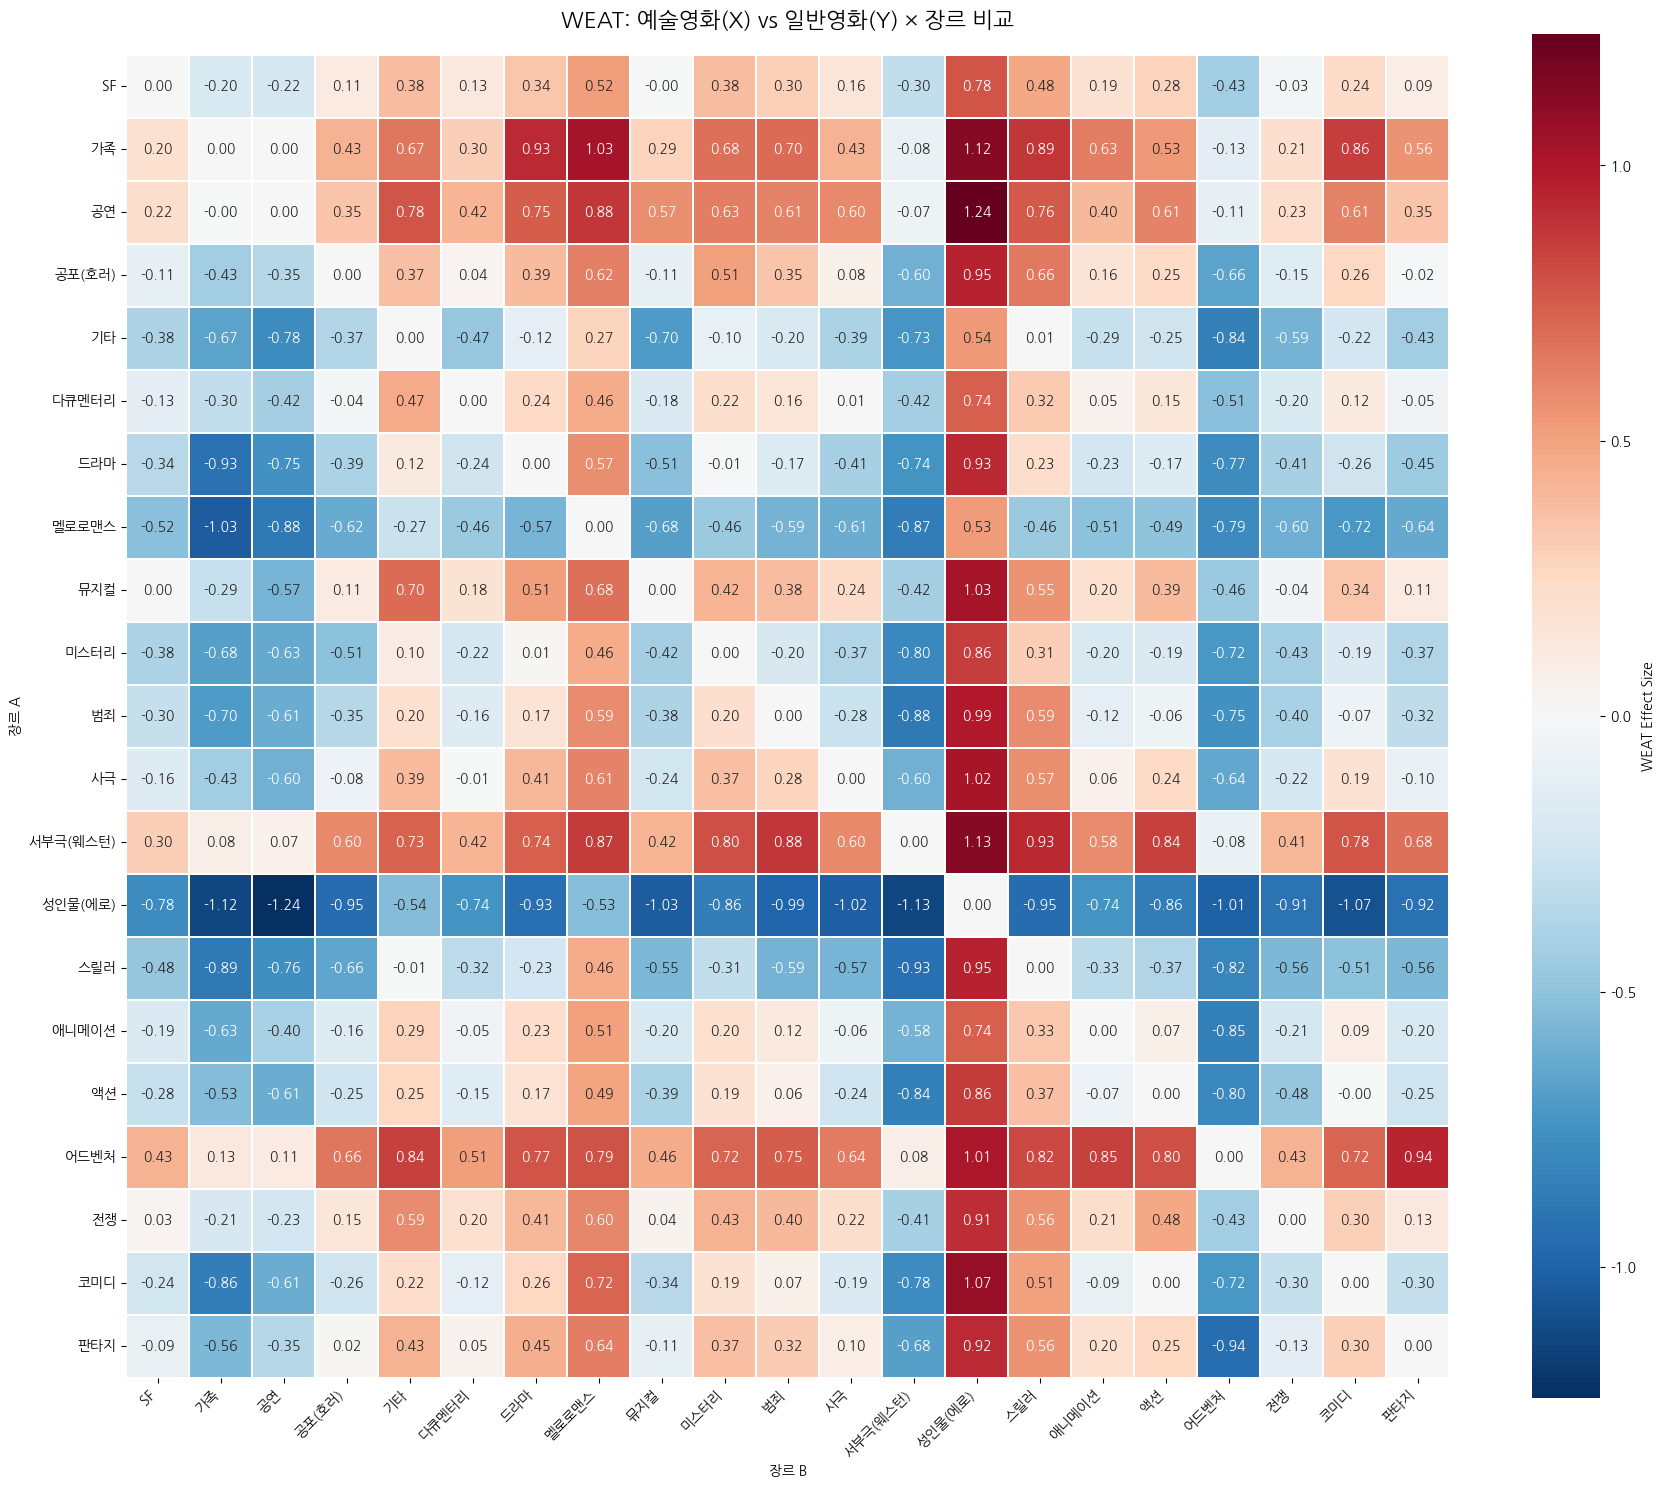

저장 완료:
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX05_word2vec_weat/figures/weat_genre_heatmap.png


In [101]:
# STEP 4-9A. WEAT Heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

weat_df = pd.DataFrame(
    weat_matrix,
    index=genre_name,
    columns=genre_name
)

plt.figure(figsize=(18, 15))

sns.heatmap(
    weat_df,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.3,
    cbar_kws={
        "label": "WEAT Effect Size"
    }
)

plt.title(
    "WEAT: 예술영화(X) vs 일반영화(Y) × 장르 비교",
    fontsize=16,
    pad=20
)

plt.xlabel("장르 B")
plt.ylabel("장르 A")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

WEAT_HEATMAP_PATH = (
    FIGURE_DIR
    / "weat_genre_heatmap.png"
)

plt.savefig(
    WEAT_HEATMAP_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("저장 완료:")
print(WEAT_HEATMAP_PATH)

In [102]:
# STEP 4-10. 절대 WEAT가 큰 장르 pair Top 15

pair_results = []

for i in range(len(genre_name)):
    for j in range(i + 1, len(genre_name)):

        A = genre_name[i]
        B = genre_name[j]
        score = weat_matrix[i, j]

        pair_results.append({
            "genre_A": A,
            "genre_B": B,
            "weat_score": score,
            "abs_score": abs(score)
        })

pair_df = pd.DataFrame(pair_results)

pair_df = pair_df.sort_values(
    "abs_score",
    ascending=False
).reset_index(drop=True)

print("[절대 WEAT Effect Size Top 15]")

display(
    pair_df[
        [
            "genre_A",
            "genre_B",
            "weat_score"
        ]
    ].head(15)
)

[절대 WEAT Effect Size Top 15]


,genre_A,genre_B,weat_score
0,공연,성인물(에로),1.237611
1,서부극(웨스턴),성인물(에로),1.127053
2,가족,성인물(에로),1.124847
3,성인물(에로),코미디,-1.074462
4,뮤지컬,성인물(에로),1.031214
5,가족,멜로로맨스,1.028547
6,사극,성인물(에로),1.021346
7,성인물(에로),어드벤처,-1.013296
8,범죄,성인물(에로),0.988677
9,공포(호러),성인물(에로),0.954557


In [103]:
# STEP 4-11. WEAT 차이가 가장 작은 pair

near_zero_df = pair_df.sort_values(
    "abs_score",
    ascending=True
).reset_index(drop=True)

print("[WEAT가 0에 가까운 장르 pair Top 10]")

display(
    near_zero_df[
        [
            "genre_A",
            "genre_B",
            "weat_score"
        ]
    ].head(10)
)

[WEAT가 0에 가까운 장르 pair Top 10]


,genre_A,genre_B,weat_score
0,액션,코미디,-0.000088
1,SF,뮤지컬,-0.001426
2,가족,공연,0.004875
3,다큐멘터리,사극,0.009200
4,기타,스릴러,0.009504
5,드라마,미스터리,-0.013381
6,공포(호러),판타지,-0.016477
7,SF,전쟁,-0.032216
8,공포(호러),다큐멘터리,0.037993
9,뮤지컬,전쟁,-0.042693


In [104]:
# STEP 4-12. WEAT 결과 저장

WEAT_MATRIX_PATH = (
    RESULT_DIR
    / "weat_genre_matrix.csv"
)

WEAT_PAIR_PATH = (
    RESULT_DIR
    / "weat_genre_pairs.csv"
)

weat_df.to_csv(
    WEAT_MATRIX_PATH,
    encoding="utf-8-sig"
)

pair_df.to_csv(
    WEAT_PAIR_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료")
print(WEAT_MATRIX_PATH)
print(WEAT_PAIR_PATH)

저장 완료
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX05_word2vec_weat/results/weat_genre_matrix.csv
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX05_word2vec_weat/results/weat_genre_pairs.csv


# 결과 해석

`WEAT 분석 결과`

예술영화와 일반영화를 Target 집합 X/Y로, 21개 영화 장르의 대표 단어를 Attribute 집합으로 설정하여 모든 장르 조합에 대한 WEAT effect size를 계산했다.

계산된 21×21 행렬은 WEAT(A,B) = -WEAT(B,A)의 anti-symmetry를 정확히 만족하여 구현의 수학적 일관성을 확인했다.

최종 분석에서는 공연-성인물(에로) 비교에서 약 +1.238, 서부극(웨스턴)-성인물 비교에서 약 +1.127, 가족-성인물 비교에서 약 +1.125의 비교적 큰 effect size가 나타났다. 본 실험의 부호 정의에 따르면 이는 각 비교에서 전자의 장르가 후자의 장르보다 상대적으로 예술영화 Target과 더 강한 연관성을 나타냈음을 의미한다.

반면 액션-코미디(-0.0001), SF-뮤지컬(-0.0014), 가족-공연(+0.0049) 등은 0에 매우 가까운 값을 보여, 예술영화-일반영화 Target 축을 기준으로 두 장르의 상대적 연관성 차이가 거의 나타나지 않았다.

특히 성인물(에로)은 여러 장르와 비교했을 때 일반영화 Target 방향으로 상대적으로 구별되는 패턴을 나타냈다.

그러나 이를 장르 자체의 본질적 특성으로 일반화할 수는 없다. 본 결과는 영화 시놉시스 코퍼스에서 학습된 Word2Vec 공간과 TF-IDF 기반 대표 단어 집합에 의존하는 상대적 association 결과이다.

`한계`

원본 시놉시스 데이터에는 영화별 document boundary가 명시적으로 제공되지 않아 범주 전체를 하나의 document로 취급하여 대표 단어를 선정했다. 또한 범주별 데이터 규모가 크게 달랐으며, 일부 장르의 대표 단어에는 특정 작품의 등장인물과 고유명사가 포함됐다. 영화제·상영 이력 등의 메타데이터성 표현도 데이터에서 관찰되어 일부는 대표어 선정 과정에서 제외했다.

초기 분석에서는 Target과 Attribute 집합에 동일 단어가 포함될 수 있음을 추가로 발견했다. 동일 단어의 cosine similarity가 1이 되어 WEAT에 직접 영향을 미칠 수 있으므로, 최종 분석에서는 Target과 장르 대표 단어 간 중복을 제거하고 장르 대표어를 재선정했다.

따라서 본 결과는 예술영화와 일반영화 또는 각 장르의 보편적인 성질을 판정한 것이 아니라, 주어진 코퍼스와 현재 전처리·임베딩·대표어 선정 조건에서 관찰된 상대적 의미 연관성으로 제한하여 해석한다.

In [105]:
# FINAL. 최종 Word Set 다시 저장

final_wordsets = {
    "target": {
        "X_art": target_X,
        "Y_gen": target_Y,
    },
    "genres": genre_wordsets,
    "method": {
        "target": "TF-IDF(own) - TF-IDF(other)",
        "genre": "TF-IDF(own) - max(TF-IDF(other genres))",
        "target_topn": len(target_X),
        "genre_topn": 15,
        "target_genre_overlap_removed": True,
    }
}

with open(
    FINAL_WORDSETS_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        final_wordsets,
        f,
        ensure_ascii=False,
        indent=2
    )

print("최종 wordset 저장 완료")
print(FINAL_WORDSETS_PATH)

최종 wordset 저장 완료
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX05_word2vec_weat/wordsets/weat_wordsets.json


In [106]:
print("[FINAL CHECK]")
print("WEAT matrix :", weat_matrix.shape)
print("NaN         :", np.isnan(weat_matrix).sum())
print(
    "Anti-symmetry error:",
    np.max(np.abs(weat_matrix + weat_matrix.T))
)
print("Target X    :", len(target_X))
print("Target Y    :", len(target_Y))
print(
    "Genre sets :",
    len(genre_wordsets),
    "×",
    len(next(iter(genre_wordsets.values())))
)

[FINAL CHECK]
WEAT matrix : (21, 21)
NaN         : 0
Anti-symmetry error: 0.0
Target X    : 15
Target Y    : 15
Genre sets : 21 × 15
